#PPO_LSTM.ipynb


<p>
Goal: add memory to goal.
</p>

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp -r /content/drive/MyDrive/'Colab Notebooks'/.ssh /root/

In [15]:
# Colab cell: Symbolic Delayed Match-to-Sample with MLP-only PPO baseline

!pip -q install gymnasium matplotlib

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# ============================================================
# Config
# ============================================================
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

TOTAL_STEPS = 100_000
CHECKPOINT_EVERY = 50_000
OUT_DIR = "/content/symbolic_dms_mlp_ppo"
os.makedirs(OUT_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ============================================================
# Symbolic Delayed Match-to-Sample
# ============================================================
class DelayedMatchToSampleEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self, delay_len=8, render_mode=None):
        super().__init__()
        self.delay_len = delay_len
        self.render_mode = render_mode

        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(4,), dtype=np.float32
        )

        self.sample = 0
        self.t = 0
        self.phase = "sample"
        self.done = False

    def _get_obs(self):
        if self.phase == "sample":
            if self.sample == 0:
                return np.array([1, 0, 0, 0], dtype=np.float32)  # A
            else:
                return np.array([0, 1, 0, 0], dtype=np.float32)  # B
        elif self.phase == "delay":
            return np.array([0, 0, 1, 0], dtype=np.float32)
        else:
            return np.array([0, 0, 0, 1], dtype=np.float32)

    def _get_info(self, success=False):
        return {
            "sample": int(self.sample),
            "phase": self.phase,
            "success": bool(success),
        }

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.sample = int(self.np_random.choice([0, 1]))  # 0=A, 1=B
        self.t = 0
        self.phase = "sample"
        self.done = False
        return self._get_obs(), self._get_info(success=False)

    def step(self, action):
        if self.done:
            raise RuntimeError("Episode done. Call reset().")

        reward = -0.01
        terminated = False
        truncated = False
        success = False

        if self.phase == "sample":
            if action != 0:
                reward -= 0.02
            self.phase = "delay"
            self.t = 0

        elif self.phase == "delay":
            if action != 0:
                reward -= 0.02
            self.t += 1
            if self.t >= self.delay_len:
                self.phase = "choice"

        else:  # choice
            correct_action = 1 if self.sample == 0 else 2
            if action == correct_action:
                reward = 1.0
                success = True
            else:
                reward = -1.0
            terminated = True
            self.done = True

        obs = self._get_obs() if not self.done else np.zeros(4, dtype=np.float32)
        info = self._get_info(success=success)

        if self.render_mode == "human":
            self.render()

        return obs, reward, terminated, truncated, info

    def render(self):
        if self.phase == "sample":
            s = "A" if self.sample == 0 else "B"
            print(f"phase=sample | sample={s}")
        elif self.phase == "delay":
            print(f"phase=delay | t={self.t}/{self.delay_len}")
        else:
            print("phase=choice | choose A or B")

# ============================================================
# MLP-only actor-critic
# ============================================================
class MLPActorCritic(nn.Module):
    def __init__(self, obs_dim, num_actions, hidden_dim=64):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
        self.pi = nn.Linear(hidden_dim, num_actions)
        self.v = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        z = self.body(x)
        logits = self.pi(z)
        value = self.v(z).squeeze(-1)
        return logits, value

# ============================================================
# Helpers
# ============================================================
def to_tensor_obs(obs):
    return torch.from_numpy(np.asarray(obs, dtype=np.float32)).unsqueeze(0).to(device)

def compute_gae(rewards, dones, values, next_value, gamma=0.99, lam=0.95):
    T = len(rewards)
    adv = torch.zeros(T, device=device)
    last = 0.0
    for t in reversed(range(T)):
        if t == T - 1:
            next_nonterminal = 1.0 - dones[t]
            next_values = next_value
        else:
            next_nonterminal = 1.0 - dones[t]
            next_values = values[t + 1]
        delta = rewards[t] + gamma * next_values * next_nonterminal - values[t]
        last = delta + gamma * lam * next_nonterminal * last
        adv[t] = last
    ret = adv + values
    return adv, ret

def evaluate_policy(model, delay_len=8, episodes=200, greedy=True):
    env = DelayedMatchToSampleEnv(delay_len=delay_len)
    success = 0
    ret_sum = 0.0

    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + 10000 + ep)
        done = False
        ep_ret = 0.0
        final_success = False

        while not done:
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                logits, _ = model(obs_t)
                if greedy:
                    action = torch.argmax(logits, dim=-1).item()
                else:
                    dist = Categorical(logits=logits)
                    action = dist.sample().item()

            obs, reward, term, trunc, info = env.step(action)
            ep_ret += reward
            final_success = info["success"]
            done = term or trunc

        ret_sum += ep_ret
        if final_success:
            success += 1

    env.close()
    return success / episodes, ret_sum / episodes

# ============================================================
# Train MLP-only PPO
# ============================================================
def train_dms_mlp_ppo(total_steps=100_000, delay_len=8):
    env = DelayedMatchToSampleEnv(delay_len=delay_len)
    model = MLPActorCritic(obs_dim=4, num_actions=env.action_space.n, hidden_dim=64).to(device)
    opt = optim.Adam(model.parameters(), lr=3e-4)

    rollout_steps = 64
    ppo_epochs = 4
    clip_coef = 0.2
    vf_coef = 0.5
    ent_coef = 1e-3

    global_step = 0
    best_success = -1.0
    ep_ret = 0.0
    episode_returns = deque(maxlen=50)

    obs, _ = env.reset(seed=SEED)

    metrics = {
        "steps": [],
        "success_greedy": [],
        "success_stochastic": [],
        "avg_return_greedy": [],
        "avg_return_stochastic": [],
        "best_success_greedy": [],
    }

    while global_step < total_steps:
        obs_buf, act_buf, logp_buf, rew_buf, done_buf, val_buf = [], [], [], [], [], []

        for _ in range(rollout_steps):
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                logits, value = model(obs_t)
                dist = Categorical(logits=logits)
                action = dist.sample()
                logp = dist.log_prob(action)

            next_obs, reward, term, trunc, info = env.step(action.item())
            done = term or trunc

            obs_buf.append(obs_t.squeeze(0))
            act_buf.append(action.squeeze(0) if action.ndim > 0 else action)
            logp_buf.append(logp.squeeze(0) if logp.ndim > 0 else logp)
            rew_buf.append(torch.tensor(reward, dtype=torch.float32, device=device))
            done_buf.append(torch.tensor(float(done), dtype=torch.float32, device=device))
            val_buf.append(value.squeeze(0) if value.ndim > 0 else value)

            ep_ret += reward
            global_step += 1
            obs = next_obs

            if done:
                episode_returns.append(ep_ret)
                ep_ret = 0.0
                obs, _ = env.reset()

            if global_step % CHECKPOINT_EVERY == 0:
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(OUT_DIR, f"dms_mlp_ppo_{global_step}.pt"),
                )

            if global_step >= total_steps:
                break

        with torch.no_grad():
            obs_t = to_tensor_obs(obs)
            _, next_value = model(obs_t)

        rewards = torch.stack(rew_buf)
        dones = torch.stack(done_buf)
        values = torch.stack(val_buf)

        adv, ret = compute_gae(rewards, dones, values, next_value.squeeze(0))
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        obs_batch = torch.stack(obs_buf)
        act_batch = torch.stack(act_buf)
        old_logp = torch.stack(logp_buf)

        for _ in range(ppo_epochs):
            logits, new_values = model(obs_batch)
            dist = Categorical(logits=logits)
            new_logp = dist.log_prob(act_batch)
            ent = dist.entropy().mean()

            ratio = (new_logp - old_logp).exp()
            pg1 = -adv * ratio
            pg2 = -adv * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
            policy_loss = torch.max(pg1, pg2).mean()
            value_loss = 0.5 * (ret - new_values).pow(2).mean()
            loss = policy_loss + vf_coef * value_loss - ent_coef * ent

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step()

        if global_step % 5000 < rollout_steps:
            succ_g, avg_ret_g = evaluate_policy(model, delay_len=delay_len, episodes=200, greedy=True)
            succ_s, avg_ret_s = evaluate_policy(model, delay_len=delay_len, episodes=200, greedy=False)

            if succ_g > best_success:
                best_success = succ_g
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(OUT_DIR, "dms_mlp_ppo_best.pt"),
                )
                print("⭐ new best checkpoint saved")

            metrics["steps"].append(global_step)
            metrics["success_greedy"].append(succ_g)
            metrics["success_stochastic"].append(succ_s)
            metrics["avg_return_greedy"].append(avg_ret_g)
            metrics["avg_return_stochastic"].append(avg_ret_s)
            metrics["best_success_greedy"].append(best_success)

            print(
                f"[DMS MLP-only PPO] step {global_step:6d} | "
                f"greedy success {succ_g:.3f} | greedy avg_ret {avg_ret_g:.3f} | "
                f"stoch success {succ_s:.3f} | stoch avg_ret {avg_ret_s:.3f} | "
                f"best greedy {best_success:.3f}",
                flush=True,
            )

    env.close()
    return model, metrics

dms_mlp_model, dms_mlp_metrics = train_dms_mlp_ppo(TOTAL_STEPS, delay_len=8)

plt.figure(figsize=(9, 4))
plt.plot(dms_mlp_metrics["steps"], dms_mlp_metrics["success_greedy"], marker="o", label="greedy success")
plt.plot(dms_mlp_metrics["steps"], dms_mlp_metrics["success_stochastic"], marker="o", label="stochastic success")
plt.plot(dms_mlp_metrics["steps"], dms_mlp_metrics["best_success_greedy"], marker="o", label="best greedy success")
plt.xlabel("env steps")
plt.ylabel("success rate")
plt.title("MLP-only PPO on Symbolic Delayed Match-to-Sample")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(dms_mlp_metrics["steps"], dms_mlp_metrics["avg_return_greedy"], marker="o", label="greedy avg return")
plt.plot(dms_mlp_metrics["steps"], dms_mlp_metrics["avg_return_stochastic"], marker="o", label="stochastic avg return")
plt.xlabel("env steps")
plt.ylabel("average return")
plt.title("Average Return on Symbolic Delayed Match-to-Sample")
plt.legend()
plt.grid(True)
plt.show()

device: cuda
gpu: Tesla T4
⭐ new best checkpoint saved
[DMS MLP-only PPO] step   5056 | greedy success 0.475 | greedy avg_ret -0.320 | stoch success 0.485 | stoch avg_ret -0.268 | best greedy 0.475
[DMS MLP-only PPO] step  10048 | greedy success 0.475 | greedy avg_ret -0.320 | stoch success 0.485 | stoch avg_ret -0.289 | best greedy 0.475
[DMS MLP-only PPO] step  15040 | greedy success 0.475 | greedy avg_ret -0.320 | stoch success 0.470 | stoch avg_ret -0.316 | best greedy 0.475
[DMS MLP-only PPO] step  20032 | greedy success 0.475 | greedy avg_ret -0.320 | stoch success 0.470 | stoch avg_ret -0.321 | best greedy 0.475
[DMS MLP-only PPO] step  25024 | greedy success 0.475 | greedy avg_ret -0.160 | stoch success 0.485 | stoch avg_ret -0.180 | best greedy 0.475


KeyboardInterrupt: 

device: cuda
gpu: Tesla T4
⭐ new best checkpoint saved
[DMS PPO+LSTM] step   5056 | greedy success 0.525 | greedy avg_ret -0.151 | stoch success 0.310 | stoch avg_ret -0.589 | best greedy 0.525
[DMS PPO+LSTM] step  10048 | greedy success 0.475 | greedy avg_ret -0.311 | stoch success 0.320 | stoch avg_ret -0.591 | best greedy 0.525
[DMS PPO+LSTM] step  15040 | greedy success 0.475 | greedy avg_ret -0.300 | stoch success 0.405 | stoch avg_ret -0.418 | best greedy 0.525
[DMS PPO+LSTM] step  20032 | greedy success 0.475 | greedy avg_ret -0.300 | stoch success 0.470 | stoch avg_ret -0.288 | best greedy 0.525
[DMS PPO+LSTM] step  25024 | greedy success 0.475 | greedy avg_ret -0.280 | stoch success 0.555 | stoch avg_ret -0.111 | best greedy 0.525
[DMS PPO+LSTM] step  30016 | greedy success 0.475 | greedy avg_ret -0.140 | stoch success 0.500 | stoch avg_ret -0.176 | best greedy 0.525
[DMS PPO+LSTM] step  35008 | greedy success 0.475 | greedy avg_ret -0.200 | stoch success 0.495 | stoch avg_ret

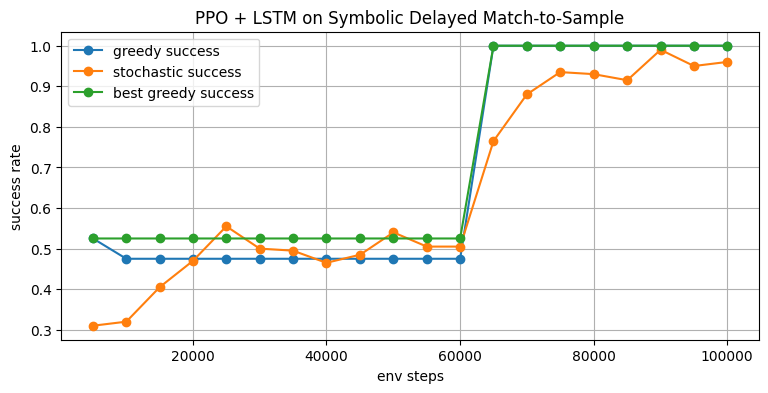

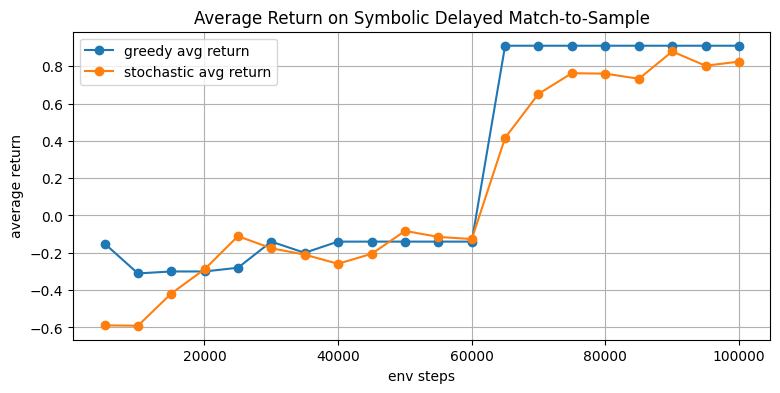

In [16]:
# Colab cell: Symbolic Delayed Match-to-Sample with PPO + LSTM

!pip -q install gymnasium matplotlib

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# ============================================================
# Config
# ============================================================
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

TOTAL_STEPS = 100_000
CHECKPOINT_EVERY = 50_000
OUT_DIR = "/content/symbolic_dms_ppo_lstm"
os.makedirs(OUT_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ============================================================
# Symbolic Delayed Match-to-Sample
# ============================================================
class DelayedMatchToSampleEnv(gym.Env):
    """
    Phases:
      0: sample shown (one step)
      1: delay (blank observations)
      2: choice (one step, choose left/right)

    Actions:
      0 = hold / no-op
      1 = choose A
      2 = choose B

    Observation shape = (4,)
      obs[0] = sample A indicator
      obs[1] = sample B indicator
      obs[2] = phase_delay indicator
      obs[3] = phase_choice indicator

    During sample phase:
      observe either [1,0,0,0] or [0,1,0,0]

    During delay:
      observe [0,0,1,0]

    During choice:
      observe [0,0,0,1]

    Correct action at choice:
      choose A if sample was A
      choose B if sample was B
    """
    metadata = {"render_modes": ["human"]}

    def __init__(self, delay_len=8, render_mode=None):
        super().__init__()
        self.delay_len = delay_len
        self.render_mode = render_mode

        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(4,), dtype=np.float32
        )

        self.sample = 0
        self.t = 0
        self.phase = "sample"
        self.done = False

    def _get_obs(self):
        if self.phase == "sample":
            if self.sample == 0:
                return np.array([1, 0, 0, 0], dtype=np.float32)  # A
            else:
                return np.array([0, 1, 0, 0], dtype=np.float32)  # B
        elif self.phase == "delay":
            return np.array([0, 0, 1, 0], dtype=np.float32)
        else:  # choice
            return np.array([0, 0, 0, 1], dtype=np.float32)

    def _get_info(self, success=False):
        return {
            "sample": int(self.sample),
            "phase": self.phase,
            "success": bool(success),
        }

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.sample = int(self.np_random.choice([0, 1]))  # 0=A, 1=B
        self.t = 0
        self.phase = "sample"
        self.done = False
        return self._get_obs(), self._get_info(success=False)

    def step(self, action):
        if self.done:
            raise RuntimeError("Episode done. Call reset().")

        reward = -0.01
        terminated = False
        truncated = False
        success = False

        if self.phase == "sample":
            # should hold during sample presentation
            if action != 0:
                reward -= 0.02
            self.phase = "delay"
            self.t = 0

        elif self.phase == "delay":
            # should hold during delay
            if action != 0:
                reward -= 0.02
            self.t += 1
            if self.t >= self.delay_len:
                self.phase = "choice"

        else:  # choice
            correct_action = 1 if self.sample == 0 else 2
            if action == correct_action:
                reward = 1.0
                success = True
            else:
                reward = -1.0
            terminated = True
            self.done = True

        obs = self._get_obs() if not self.done else np.zeros(4, dtype=np.float32)
        info = self._get_info(success=success)

        if self.render_mode == "human":
            self.render()

        return obs, reward, terminated, truncated, info

    def render(self):
        if self.phase == "sample":
            s = "A" if self.sample == 0 else "B"
            print(f"phase=sample | sample={s}")
        elif self.phase == "delay":
            print(f"phase=delay | t={self.t}/{self.delay_len}")
        else:
            print("phase=choice | choose A or B")

# ============================================================
# MLP + LSTM Actor-Critic
# ============================================================
class MLPLSTMActorCritic(nn.Module):
    def __init__(self, obs_dim, num_actions, hidden_dim=64, lstm_hidden=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
        self.lstm = nn.LSTM(hidden_dim, lstm_hidden, num_layers=1)
        self.pi = nn.Linear(lstm_hidden, num_actions)
        self.v = nn.Linear(lstm_hidden, 1)
        self.lstm_hidden = lstm_hidden

    def init_hidden(self, batch_size=1):
        h = torch.zeros(1, batch_size, self.lstm_hidden, device=device)
        c = torch.zeros(1, batch_size, self.lstm_hidden, device=device)
        return (h, c)

    def step(self, x, hidden):
        z = self.mlp(x).unsqueeze(0)  # [1,B,H]
        out, hidden = self.lstm(z, hidden)
        out = out.squeeze(0)
        logits = self.pi(out)
        value = self.v(out).squeeze(-1)
        dist = Categorical(logits=logits)
        action = dist.sample()
        logp = dist.log_prob(action)
        ent = dist.entropy()
        return action, logp, ent, value, hidden

    def greedy_step(self, x, hidden):
        z = self.mlp(x).unsqueeze(0)
        out, hidden = self.lstm(z, hidden)
        out = out.squeeze(0)
        logits = self.pi(out)
        value = self.v(out).squeeze(-1)
        action = torch.argmax(logits, dim=-1)
        return action, value, hidden

    def evaluate_seq(self, obs_seq, act_seq, hidden0):
        # obs_seq [T,B,D], act_seq [T,B]
        T, B, D = obs_seq.shape
        x = obs_seq.reshape(T * B, D)
        z = self.mlp(x).view(T, B, -1)
        out, _ = self.lstm(z, hidden0)
        logits = self.pi(out)
        values = self.v(out).squeeze(-1)
        dist = Categorical(logits=logits)
        logp = dist.log_prob(act_seq)
        ent = dist.entropy()
        return logp, ent, values

# ============================================================
# Helpers
# ============================================================
def to_tensor_obs(obs):
    return torch.from_numpy(np.asarray(obs, dtype=np.float32)).unsqueeze(0).to(device)

def compute_gae(rewards, dones, values, next_value, gamma=0.99, lam=0.95):
    T = len(rewards)
    adv = torch.zeros(T, device=device)
    last = 0.0
    for t in reversed(range(T)):
        if t == T - 1:
            next_nonterminal = 1.0 - dones[t]
            next_values = next_value
        else:
            next_nonterminal = 1.0 - dones[t]
            next_values = values[t + 1]
        delta = rewards[t] + gamma * next_values * next_nonterminal - values[t]
        last = delta + gamma * lam * next_nonterminal * last
        adv[t] = last
    ret = adv + values
    return adv, ret

def evaluate_policy(model, delay_len=8, episodes=200, greedy=True):
    env = DelayedMatchToSampleEnv(delay_len=delay_len)
    success = 0
    ret_sum = 0.0

    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + 10000 + ep)
        done = False
        ep_ret = 0.0
        final_success = False
        hidden = model.init_hidden(1)

        while not done:
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                if greedy:
                    action, _, hidden = model.greedy_step(obs_t, hidden)
                    action = action.item()
                else:
                    action, _, _, _, hidden = model.step(obs_t, hidden)
                    action = action.item()

            obs, reward, term, trunc, info = env.step(action)
            ep_ret += reward
            final_success = info["success"]
            done = term or trunc

        ret_sum += ep_ret
        if final_success:
            success += 1

    env.close()
    return success / episodes, ret_sum / episodes

# ============================================================
# Train PPO + LSTM
# ============================================================
def train_dms_ppo_lstm(total_steps=100_000, delay_len=8):
    env = DelayedMatchToSampleEnv(delay_len=delay_len)
    model = MLPLSTMActorCritic(obs_dim=4, num_actions=env.action_space.n, hidden_dim=64, lstm_hidden=64).to(device)
    opt = optim.Adam(model.parameters(), lr=1e-4)

    rollout_steps = 64
    ppo_epochs = 4
    clip_coef = 0.2
    vf_coef = 0.5
    ent_coef = 1e-3

    global_step = 0
    best_success = -1.0
    ep_ret = 0.0
    episode_returns = deque(maxlen=50)

    obs, _ = env.reset(seed=SEED)
    hidden = model.init_hidden(1)

    metrics = {
        "steps": [],
        "success_greedy": [],
        "success_stochastic": [],
        "avg_return_greedy": [],
        "avg_return_stochastic": [],
        "best_success_greedy": [],
    }

    while global_step < total_steps:
        obs_buf, act_buf, logp_buf, rew_buf, done_buf, val_buf = [], [], [], [], [], []
        hidden0 = (hidden[0].detach().clone(), hidden[1].detach().clone())

        for _ in range(rollout_steps):
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                action, logp, ent, value, hidden = model.step(obs_t, hidden)

            next_obs, reward, term, trunc, info = env.step(action.item())
            done = term or trunc

            obs_buf.append(obs_t.squeeze(0))
            act_buf.append(action.squeeze(0) if action.ndim > 0 else action)
            logp_buf.append(logp.squeeze(0) if logp.ndim > 0 else logp)
            rew_buf.append(torch.tensor(reward, dtype=torch.float32, device=device))
            done_buf.append(torch.tensor(float(done), dtype=torch.float32, device=device))
            val_buf.append(value.squeeze(0) if value.ndim > 0 else value)

            ep_ret += reward
            global_step += 1
            obs = next_obs

            if done:
                episode_returns.append(ep_ret)
                ep_ret = 0.0
                obs, _ = env.reset()
                hidden = model.init_hidden(1)
            else:
                hidden = (hidden[0].detach(), hidden[1].detach())

            if global_step % CHECKPOINT_EVERY == 0:
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(OUT_DIR, f"dms_ppo_lstm_{global_step}.pt"),
                )

            if global_step >= total_steps:
                break

        with torch.no_grad():
            obs_t = to_tensor_obs(obs)
            _, _, _, next_value, _ = model.step(obs_t, hidden)

        rewards = torch.stack(rew_buf)
        dones = torch.stack(done_buf)
        values = torch.stack(val_buf)

        adv, ret = compute_gae(rewards, dones, values, next_value.squeeze(0))
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        obs_seq = torch.stack(obs_buf).unsqueeze(1)  # [T,1,D]
        act_seq = torch.stack(act_buf).view(-1, 1)
        old_logp = torch.stack(logp_buf).view(-1, 1)
        adv_seq = adv.view(-1, 1)
        ret_seq = ret.view(-1, 1)

        for _ in range(ppo_epochs):
            new_logp, ent, new_values = model.evaluate_seq(obs_seq, act_seq, hidden0)

            ratio = (new_logp - old_logp).exp()
            pg1 = -adv_seq * ratio
            pg2 = -adv_seq * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
            policy_loss = torch.max(pg1, pg2).mean()
            value_loss = 0.5 * (ret_seq - new_values).pow(2).mean()
            ent_loss = ent.mean()
            loss = policy_loss + vf_coef * value_loss - ent_coef * ent_loss

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step()

        if global_step % 5000 < rollout_steps:
            succ_g, avg_ret_g = evaluate_policy(model, delay_len=delay_len, episodes=200, greedy=True)
            succ_s, avg_ret_s = evaluate_policy(model, delay_len=delay_len, episodes=200, greedy=False)

            if succ_g > best_success:
                best_success = succ_g
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(OUT_DIR, "dms_ppo_lstm_best.pt"),
                )
                print("⭐ new best checkpoint saved")

            metrics["steps"].append(global_step)
            metrics["success_greedy"].append(succ_g)
            metrics["success_stochastic"].append(succ_s)
            metrics["avg_return_greedy"].append(avg_ret_g)
            metrics["avg_return_stochastic"].append(avg_ret_s)
            metrics["best_success_greedy"].append(best_success)

            print(
                f"[DMS PPO+LSTM] step {global_step:6d} | "
                f"greedy success {succ_g:.3f} | greedy avg_ret {avg_ret_g:.3f} | "
                f"stoch success {succ_s:.3f} | stoch avg_ret {avg_ret_s:.3f} | "
                f"best greedy {best_success:.3f}",
                flush=True,
            )

    env.close()
    return model, metrics

dms_model, dms_metrics = train_dms_ppo_lstm(TOTAL_STEPS, delay_len=8)

plt.figure(figsize=(9, 4))
plt.plot(dms_metrics["steps"], dms_metrics["success_greedy"], marker="o", label="greedy success")
plt.plot(dms_metrics["steps"], dms_metrics["success_stochastic"], marker="o", label="stochastic success")
plt.plot(dms_metrics["steps"], dms_metrics["best_success_greedy"], marker="o", label="best greedy success")
plt.xlabel("env steps")
plt.ylabel("success rate")
plt.title("PPO + LSTM on Symbolic Delayed Match-to-Sample")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(dms_metrics["steps"], dms_metrics["avg_return_greedy"], marker="o", label="greedy avg return")
plt.plot(dms_metrics["steps"], dms_metrics["avg_return_stochastic"], marker="o", label="stochastic avg return")
plt.xlabel("env steps")
plt.ylabel("average return")
plt.title("Average Return on Symbolic Delayed Match-to-Sample")
plt.legend()
plt.grid(True)
plt.show()

device: cuda
gpu: Tesla T4
⭐ new best checkpoint saved
[Recurrent DQN] step   5000 | greedy success 1.000 | greedy avg_ret 10.104 | sampled success 0.250 | sampled avg_ret 2.474 | best greedy 1.000 | eps 0.905
[Recurrent DQN] step  10000 | greedy success 1.000 | greedy avg_ret 10.120 | sampled success 0.600 | sampled avg_ret 6.038 | best greedy 1.000 | eps 0.810
[Recurrent DQN] step  15000 | greedy success 0.525 | greedy avg_ret 5.296 | sampled success 0.260 | sampled avg_ret 2.580 | best greedy 1.000 | eps 0.715
[Recurrent DQN] step  20000 | greedy success 0.000 | greedy avg_ret -0.040 | sampled success 0.275 | sampled avg_ret 2.726 | best greedy 1.000 | eps 0.620
[Recurrent DQN] step  25000 | greedy success 0.000 | greedy avg_ret -0.077 | sampled success 0.110 | sampled avg_ret 1.055 | best greedy 1.000 | eps 0.525
[Recurrent DQN] step  30000 | greedy success 0.000 | greedy avg_ret -0.077 | sampled success 0.070 | sampled avg_ret 0.650 | best greedy 1.000 | eps 0.430
[Recurrent DQN] 

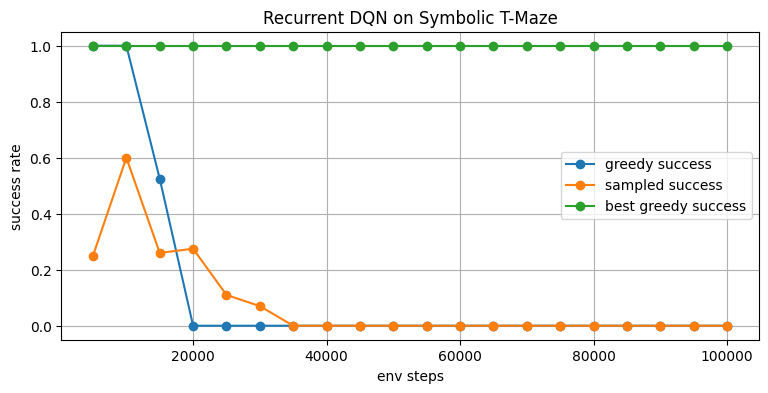

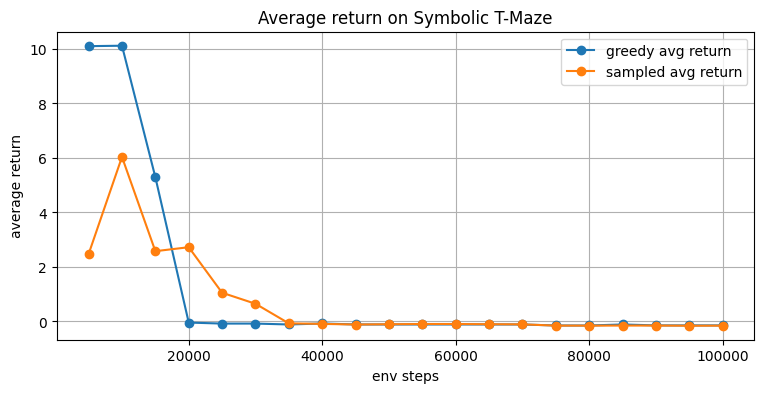

In [14]:
# Colab cell: Recurrent DQN (DRQN) on Symbolic T-Maze

!pip -q install gymnasium matplotlib

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# ============================================================
# Config
# ============================================================
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

TOTAL_STEPS = 100_000
CHECKPOINT_EVERY = 50_000
OUT_DIR = "/content/symbolic_tmaze_recurrent_dqn"
os.makedirs(OUT_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ============================================================
# Symbolic T-Maze
# ============================================================
class SymbolicTMazeEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self, corridor_length=3, max_steps=None, render_mode=None):
        super().__init__()
        self.corridor_length = corridor_length
        self.max_steps = max_steps if max_steps is not None else corridor_length + 3
        self.render_mode = render_mode

        self.action_space = spaces.Discrete(3)  # 0=forward, 1=left, 2=right
        self.observation_space = spaces.Box(
            low=np.array([0.0, -1.0, 0.0], dtype=np.float32),
            high=np.array([1.0,  1.0, 1.0], dtype=np.float32),
            dtype=np.float32,
        )

        self.pos = 0
        self.cue = 0
        self.done = False
        self.steps = 0

    def _get_obs(self):
        pos_norm = self.pos / self.corridor_length
        cue_val = float(self.cue) if self.pos == 0 else 0.0
        at_junction = 1.0 if self.pos == self.corridor_length else 0.0
        return np.array([pos_norm, cue_val, at_junction], dtype=np.float32)

    def _get_info(self, success=False):
        return {"pos": self.pos, "cue": int(self.cue), "success": bool(success)}

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.pos = 0
        self.done = False
        self.steps = 0
        self.cue = int(self.np_random.choice([-1, 1]))
        return self._get_obs(), self._get_info(success=False)

    def step(self, action):
        if self.done:
            raise RuntimeError("Episode done. Call reset().")

        self.steps += 1
        reward = -0.01
        terminated = False
        truncated = False
        success = False

        if self.pos < self.corridor_length:
            if action == 0:
                self.pos += 1
                reward += 0.05
            else:
                reward -= 0.02
        else:
            if action == 1:
                reward = 10.0 if self.cue == -1 else -10.0
                success = (self.cue == -1)
                terminated = True
                self.done = True
            elif action == 2:
                reward = 10.0 if self.cue == 1 else -10.0
                success = (self.cue == 1)
                terminated = True
                self.done = True
            else:
                reward = -1.0
                terminated = True
                self.done = True

        if self.steps >= self.max_steps and not terminated:
            truncated = True
            self.done = True

        return self._get_obs(), reward, terminated, truncated, self._get_info(success=success)

# ============================================================
# Recurrent Q-network
# ============================================================
class DRQN(nn.Module):
    def __init__(self, obs_dim, num_actions, hidden_dim=64, lstm_hidden=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(hidden_dim, lstm_hidden, num_layers=1)
        self.q = nn.Linear(lstm_hidden, num_actions)
        self.lstm_hidden = lstm_hidden

    def init_hidden(self, batch_size=1):
        h = torch.zeros(1, batch_size, self.lstm_hidden, device=device)
        c = torch.zeros(1, batch_size, self.lstm_hidden, device=device)
        return (h, c)

    def forward_step(self, x, hidden):
        # x: [B, obs_dim]
        z = self.mlp(x).unsqueeze(0)   # [1,B,H]
        out, hidden = self.lstm(z, hidden)
        out = out.squeeze(0)
        q = self.q(out)
        return q, hidden

    def forward_seq(self, obs_seq, hidden0):
        # obs_seq: [T,B,obs_dim]
        T, B, D = obs_seq.shape
        x = obs_seq.reshape(T * B, D)
        z = self.mlp(x).view(T, B, -1)
        out, hidden = self.lstm(z, hidden0)
        q = self.q(out)  # [T,B,A]
        return q, hidden

# ============================================================
# Episode replay
# ============================================================
class EpisodeReplay:
    def __init__(self, capacity=5000):
        self.buffer = deque(maxlen=capacity)

    def add_episode(self, episode):
        self.buffer.append(episode)

    def __len__(self):
        return len(self.buffer)

    def sample_sequences(self, batch_size, seq_len):
        batch = random.sample(self.buffer, min(batch_size, len(self.buffer)))
        obs_b, act_b, rew_b, next_obs_b, done_b = [], [], [], [], []

        for ep in batch:
            if len(ep["obs"]) >= seq_len:
                start = random.randint(0, len(ep["obs"]) - seq_len)
                end = start + seq_len
            else:
                start = 0
                end = len(ep["obs"])

            obs = ep["obs"][start:end]
            act = ep["act"][start:end]
            rew = ep["rew"][start:end]
            nxt = ep["next_obs"][start:end]
            don = ep["done"][start:end]

            pad = seq_len - len(obs)
            if pad > 0:
                zero_obs = np.zeros_like(obs[0])
                obs = obs + [zero_obs] * pad
                nxt = nxt + [zero_obs] * pad
                act = act + [0] * pad
                rew = rew + [0.0] * pad
                don = don + [1.0] * pad

            obs_b.append(np.stack(obs))
            act_b.append(np.array(act, dtype=np.int64))
            rew_b.append(np.array(rew, dtype=np.float32))
            next_obs_b.append(np.stack(nxt))
            done_b.append(np.array(don, dtype=np.float32))

        obs_b = torch.from_numpy(np.stack(obs_b)).to(device=device, dtype=torch.float32)         # [B,T,D]
        act_b = torch.from_numpy(np.stack(act_b)).to(device=device, dtype=torch.long)             # [B,T]
        rew_b = torch.from_numpy(np.stack(rew_b)).to(device=device, dtype=torch.float32)
        next_obs_b = torch.from_numpy(np.stack(next_obs_b)).to(device=device, dtype=torch.float32)
        done_b = torch.from_numpy(np.stack(done_b)).to(device=device, dtype=torch.float32)
        return obs_b, act_b, rew_b, next_obs_b, done_b

# ============================================================
# Helpers
# ============================================================
def to_tensor_obs(obs):
    return torch.from_numpy(np.asarray(obs, dtype=np.float32)).unsqueeze(0).to(device)

def evaluate_drqn(model, episodes=200, greedy=True):
    env = SymbolicTMazeEnv(corridor_length=3)
    success = 0
    ret_sum = 0.0

    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + 10000 + ep)
        hidden = model.init_hidden(1)
        done = False
        ep_ret = 0.0
        final_success = False

        while not done:
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                q, hidden = model.forward_step(obs_t, hidden)

            if greedy:
                action = int(torch.argmax(q, dim=-1).item())
            else:
                # small eval-time epsilon could be added, but keep pure greedy/random split
                probs = torch.softmax(q, dim=-1)
                action = int(torch.multinomial(probs, num_samples=1).item())

            obs, reward, term, trunc, info = env.step(action)
            ep_ret += reward
            final_success = info["success"]
            done = term or trunc

        ret_sum += ep_ret
        if final_success:
            success += 1

    env.close()
    return success / episodes, ret_sum / episodes

# ============================================================
# Train DRQN
# ============================================================
def train_recurrent_dqn(total_steps=100_000):
    env = SymbolicTMazeEnv(corridor_length=3)
    qnet = DRQN(obs_dim=3, num_actions=env.action_space.n, hidden_dim=64, lstm_hidden=64).to(device)
    target = DRQN(obs_dim=3, num_actions=env.action_space.n, hidden_dim=64, lstm_hidden=64).to(device)
    target.load_state_dict(qnet.state_dict())

    opt = optim.Adam(qnet.parameters(), lr=1e-4)

    replay = EpisodeReplay(capacity=4000)
    seq_len = 8
    batch_size = 32
    gamma = 0.99
    train_freq = 4
    target_update = 1000
    learning_starts = 1000

    eps_start = 1.0
    eps_end = 0.05
    eps_decay = 50_000

    global_step = 0
    best_success = -1.0
    episode_returns = deque(maxlen=50)

    obs, _ = env.reset(seed=SEED)
    hidden = qnet.init_hidden(1)

    episode = {"obs": [], "act": [], "rew": [], "next_obs": [], "done": []}
    ep_ret = 0.0

    metrics = {
        "steps": [],
        "success_greedy": [],
        "success_sampled": [],
        "avg_return_greedy": [],
        "avg_return_sampled": [],
        "best_success_greedy": [],
    }

    while global_step < total_steps:
        epsilon = max(eps_end, eps_start - (eps_start - eps_end) * (global_step / eps_decay))
        obs_t = to_tensor_obs(obs)

        with torch.no_grad():
            qvals, hidden_next = qnet.forward_step(obs_t, hidden)

        if random.random() < epsilon:
            action = random.randrange(env.action_space.n)
        else:
            action = int(torch.argmax(qvals, dim=-1).item())

        next_obs, reward, term, trunc, info = env.step(action)
        done = term or trunc

        episode["obs"].append(obs.astype(np.float32))
        episode["act"].append(action)
        episode["rew"].append(float(reward))
        episode["next_obs"].append(next_obs.astype(np.float32))
        episode["done"].append(float(done))

        ep_ret += reward
        global_step += 1
        obs = next_obs
        hidden = (hidden_next[0].detach(), hidden_next[1].detach())

        if done:
            replay.add_episode(episode)
            episode_returns.append(ep_ret)
            ep_ret = 0.0
            episode = {"obs": [], "act": [], "rew": [], "next_obs": [], "done": []}
            obs, _ = env.reset()
            hidden = qnet.init_hidden(1)

        if global_step >= learning_starts and global_step % train_freq == 0 and len(replay) >= batch_size:
            obs_b, act_b, rew_b, next_obs_b, done_b = replay.sample_sequences(batch_size, seq_len)

            # [B,T,D] -> [T,B,D]
            obs_seq = obs_b.transpose(0, 1)
            next_obs_seq = next_obs_b.transpose(0, 1)
            act_seq = act_b.transpose(0, 1)
            rew_seq = rew_b.transpose(0, 1)
            done_seq = done_b.transpose(0, 1)

            h0 = qnet.init_hidden(batch_size)
            q_seq, _ = qnet.forward_seq(obs_seq, h0)                 # [T,B,A]
            q_taken = q_seq.gather(-1, act_seq.unsqueeze(-1)).squeeze(-1)

            with torch.no_grad():
                h1 = qnet.init_hidden(batch_size)
                next_q_online, _ = qnet.forward_seq(next_obs_seq, h1)
                next_actions = next_q_online.argmax(dim=-1, keepdim=True)

                h2 = target.init_hidden(batch_size)
                next_q_target, _ = target.forward_seq(next_obs_seq, h2)
                next_q = next_q_target.gather(-1, next_actions).squeeze(-1)

                targets = rew_seq + gamma * next_q * (1.0 - done_seq)

            loss = F.smooth_l1_loss(q_taken, targets)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(qnet.parameters(), 10.0)
            opt.step()

        if global_step % target_update == 0:
            target.load_state_dict(qnet.state_dict())

        if global_step % CHECKPOINT_EVERY == 0:
            torch.save(
                {
                    "step": global_step,
                    "model_state": qnet.state_dict(),
                    "target_state": target.state_dict(),
                    "opt_state": opt.state_dict(),
                    "best_success_greedy": best_success,
                },
                os.path.join(OUT_DIR, f"recurrent_dqn_{global_step}.pt"),
            )

        if global_step % 5000 == 0 and global_step > 0:
            succ_g, avg_ret_g = evaluate_drqn(qnet, episodes=200, greedy=True)
            succ_s, avg_ret_s = evaluate_drqn(qnet, episodes=200, greedy=False)

            if succ_g > best_success:
                best_success = succ_g
                torch.save(
                    {
                        "step": global_step,
                        "model_state": qnet.state_dict(),
                        "target_state": target.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(OUT_DIR, "recurrent_dqn_best.pt"),
                )
                print("⭐ new best checkpoint saved")

            metrics["steps"].append(global_step)
            metrics["success_greedy"].append(succ_g)
            metrics["success_sampled"].append(succ_s)
            metrics["avg_return_greedy"].append(avg_ret_g)
            metrics["avg_return_sampled"].append(avg_ret_s)
            metrics["best_success_greedy"].append(best_success)

            print(
                f"[Recurrent DQN] step {global_step:6d} | "
                f"greedy success {succ_g:.3f} | greedy avg_ret {avg_ret_g:.3f} | "
                f"sampled success {succ_s:.3f} | sampled avg_ret {avg_ret_s:.3f} | "
                f"best greedy {best_success:.3f} | eps {epsilon:.3f}",
                flush=True,
            )

    env.close()
    return qnet, metrics

drqn_model, drqn_metrics = train_recurrent_dqn(TOTAL_STEPS)

plt.figure(figsize=(9, 4))
plt.plot(drqn_metrics["steps"], drqn_metrics["success_greedy"], marker="o", label="greedy success")
plt.plot(drqn_metrics["steps"], drqn_metrics["success_sampled"], marker="o", label="sampled success")
plt.plot(drqn_metrics["steps"], drqn_metrics["best_success_greedy"], marker="o", label="best greedy success")
plt.xlabel("env steps")
plt.ylabel("success rate")
plt.title("Recurrent DQN on Symbolic T-Maze")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(drqn_metrics["steps"], drqn_metrics["avg_return_greedy"], marker="o", label="greedy avg return")
plt.plot(drqn_metrics["steps"], drqn_metrics["avg_return_sampled"], marker="o", label="sampled avg return")
plt.xlabel("env steps")
plt.ylabel("average return")
plt.title("Average return on Symbolic T-Maze")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# Colab cell 1: Image Delayed Match-to-Sample env + shared helpers

!pip -q install gymnasium matplotlib imageio imageio-ffmpeg pillow

import os
import random
import imageio
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from IPython.display import Video, display

SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

OUT_DIR = "/content/image_dms_compare"
CKPT_DIR = os.path.join(OUT_DIR, "checkpoints")
VID_DIR = os.path.join(OUT_DIR, "videos")
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(VID_DIR, exist_ok=True)

IMG_SIZE = 64
DELAY_LEN = 8
TOTAL_STEPS = 20_000
CHECKPOINT_EVERY = 20_000

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


class ImageDelayedMatchToSampleEnv(gym.Env):
    """
    Image-based delayed match-to-sample.

    Phases:
      sample: show pattern A or B
      delay: blank image
      choice: show both A and B, choose left/right

    Actions:
      0 = hold/no-op
      1 = choose left
      2 = choose right

    Reward:
      small step penalty
      correct choice: +1
      wrong choice: -1
      early choose in non-choice phase: extra small penalty
    """
    metadata = {"render_modes": ["rgb_array"]}

    def __init__(self, delay_len=8, image_size=64, render_mode="rgb_array"):
        super().__init__()
        self.delay_len = delay_len
        self.image_size = image_size
        self.render_mode = render_mode

        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(1, image_size, image_size), dtype=np.float32
        )

        self.sample_id = 0   # 0=A, 1=B
        self.phase = "sample"
        self.delay_t = 0
        self.done = False

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.sample_id = int(self.np_random.choice([0, 1]))
        self.phase = "sample"
        self.delay_t = 0
        self.done = False
        return self._get_obs(), self._get_info(success=False)

    def _get_info(self, success=False):
        return {
            "sample_id": int(self.sample_id),
            "phase": self.phase,
            "success": bool(success),
        }

    def _draw_pattern_A(self, img):
        h, w = img.shape
        img[h//4:3*h//4, w//2-3:w//2+3] = 1.0
        img[h//4:h//4+6, w//3:2*w//3] = 1.0
        img[h//2-3:h//2+3, w//3:2*w//3] = 1.0
        return img

    def _draw_pattern_B(self, img):
        h, w = img.shape
        img[h//4:3*h//4, w//3:w//3+6] = 1.0
        img[h//4:h//4+6, w//3:2*w//3] = 1.0
        img[h//2-3:h//2+3, w//3:2*w//3] = 1.0
        img[3*h//4-6:3*h//4, w//3:2*w//3] = 1.0
        return img

    def _sample_image(self):
        img = np.zeros((self.image_size, self.image_size), dtype=np.float32)
        if self.sample_id == 0:
            img = self._draw_pattern_A(img)
        else:
            img = self._draw_pattern_B(img)
        return img

    def _delay_image(self):
        return np.zeros((self.image_size, self.image_size), dtype=np.float32)

    def _choice_image(self):
        img = np.zeros((self.image_size, self.image_size), dtype=np.float32)
        left = np.zeros_like(img)
        right = np.zeros_like(img)

        # left box has A
        left = self._draw_pattern_A(left)
        # right box has B
        right = self._draw_pattern_B(right)

        left = np.roll(left, shift=-self.image_size // 4, axis=1)
        right = np.roll(right, shift=self.image_size // 4, axis=1)

        img = np.maximum(left, right)
        return img

    def _get_obs(self):
        if self.phase == "sample":
            img = self._sample_image()
        elif self.phase == "delay":
            img = self._delay_image()
        else:
            img = self._choice_image()

        return img[None, :, :].astype(np.float32)

    def step(self, action):
        if self.done:
            raise RuntimeError("Episode done. Call reset().")

        reward = -0.01
        terminated = False
        truncated = False
        success = False

        if self.phase == "sample":
            if action != 0:
                reward -= 0.02
            self.phase = "delay"
            self.delay_t = 0

        elif self.phase == "delay":
            if action != 0:
                reward -= 0.02
            self.delay_t += 1
            if self.delay_t >= self.delay_len:
                self.phase = "choice"

        else:  # choice
            correct_action = 1 if self.sample_id == 0 else 2
            if action == correct_action:
                reward = 1.0
                success = True
            else:
                reward = -1.0
            terminated = True
            self.done = True

        obs = self._get_obs() if not self.done else np.zeros((1, self.image_size, self.image_size), dtype=np.float32)
        info = self._get_info(success=success)
        return obs, reward, terminated, truncated, info

    def render(self):
        img = self._get_obs()[0]
        return (img * 255).astype(np.uint8)


class CNNEncoder(nn.Module):
    def __init__(self, in_ch=1, img_size=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, 8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1), nn.ReLU(),
            nn.Flatten(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, img_size, img_size)
            self.out_dim = self.net(dummy).shape[-1]

    def forward(self, x):
        return self.net(x)


class CNNActorCritic(nn.Module):
    def __init__(self, num_actions):
        super().__init__()
        self.enc = CNNEncoder(1, IMG_SIZE)
        self.fc = nn.Sequential(
            nn.Linear(self.enc.out_dim, 256),
            nn.ReLU(),
        )
        self.pi = nn.Linear(256, num_actions)
        self.v = nn.Linear(256, 1)

    def forward(self, x):
        z = self.fc(self.enc(x))
        return self.pi(z), self.v(z).squeeze(-1)


class CNNLSTMActorCritic(nn.Module):
    def __init__(self, num_actions, lstm_hidden=128):
        super().__init__()
        self.enc = CNNEncoder(1, IMG_SIZE)
        self.fc = nn.Sequential(
            nn.Linear(self.enc.out_dim, 256),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(256, lstm_hidden, num_layers=1)
        self.pi = nn.Linear(lstm_hidden, num_actions)
        self.v = nn.Linear(lstm_hidden, 1)
        self.lstm_hidden = lstm_hidden

    def init_hidden(self, batch_size=1):
        h = torch.zeros(1, batch_size, self.lstm_hidden, device=device)
        c = torch.zeros(1, batch_size, self.lstm_hidden, device=device)
        return (h, c)

    def step(self, x, hidden):
        z = self.fc(self.enc(x)).unsqueeze(0)
        out, hidden = self.lstm(z, hidden)
        out = out.squeeze(0)
        logits = self.pi(out)
        value = self.v(out).squeeze(-1)
        dist = Categorical(logits=logits)
        action = dist.sample()
        logp = dist.log_prob(action)
        ent = dist.entropy()
        return action, logp, ent, value, hidden

    def greedy_step(self, x, hidden):
        z = self.fc(self.enc(x)).unsqueeze(0)
        out, hidden = self.lstm(z, hidden)
        out = out.squeeze(0)
        logits = self.pi(out)
        value = self.v(out).squeeze(-1)
        action = torch.argmax(logits, dim=-1)
        return action, value, hidden

    def evaluate_seq(self, obs_seq, act_seq, hidden0):
        T, B = act_seq.shape
        x = obs_seq.reshape(T * B, *obs_seq.shape[2:])
        z = self.fc(self.enc(x)).view(T, B, -1)
        out, _ = self.lstm(z, hidden0)
        logits = self.pi(out)
        values = self.v(out).squeeze(-1)
        dist = Categorical(logits=logits)
        logp = dist.log_prob(act_seq)
        ent = dist.entropy()
        return logp, ent, values


def to_tensor_obs(obs):
    return torch.from_numpy(np.asarray(obs, dtype=np.float32)).unsqueeze(0).to(device)


def compute_gae(rewards, dones, values, next_value, gamma=0.99, lam=0.95):
    T = len(rewards)
    adv = torch.zeros(T, device=device)
    last = 0.0
    for t in reversed(range(T)):
        if t == T - 1:
            next_nonterminal = 1.0 - dones[t]
            next_values = next_value
        else:
            next_nonterminal = 1.0 - dones[t]
            next_values = values[t + 1]
        delta = rewards[t] + gamma * next_values * next_nonterminal - values[t]
        last = delta + gamma * lam * next_nonterminal * last
        adv[t] = last
    ret = adv + values
    return adv, ret


def evaluate_cnn_policy(model, episodes=200, greedy=True, recurrent=False):
    env = ImageDelayedMatchToSampleEnv(delay_len=DELAY_LEN, image_size=IMG_SIZE)
    success = 0
    ret_sum = 0.0

    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + 10000 + ep)
        done = False
        ep_ret = 0.0
        final_success = False
        hidden = model.init_hidden(1) if recurrent else None

        while not done:
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                if recurrent:
                    if greedy:
                        action, _, hidden = model.greedy_step(obs_t, hidden)
                        action = action.item()
                    else:
                        action, _, _, _, hidden = model.step(obs_t, hidden)
                        action = action.item()
                else:
                    logits, _ = model(obs_t)
                    if greedy:
                        action = torch.argmax(logits, dim=-1).item()
                    else:
                        dist = Categorical(logits=logits)
                        action = dist.sample().item()

            obs, reward, term, trunc, info = env.step(action)
            ep_ret += reward
            final_success = info["success"]
            done = term or trunc

        ret_sum += ep_ret
        if final_success:
            success += 1

    env.close()
    return success / episodes, ret_sum / episodes


def make_video_cnn_policy(model, path, episodes=3, recurrent=False):
    env = ImageDelayedMatchToSampleEnv(delay_len=DELAY_LEN, image_size=IMG_SIZE, render_mode="rgb_array")
    frames = []

    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + 3000 + ep)
        done = False
        hidden = model.init_hidden(1) if recurrent else None

        while not done:
            frames.append(env.render())
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                if recurrent:
                    action, _, hidden = model.greedy_step(obs_t, hidden)
                    action = action.item()
                else:
                    logits, _ = model(obs_t)
                    action = torch.argmax(logits, dim=-1).item()

            obs, reward, term, trunc, info = env.step(action)
            done = term or trunc

        for _ in range(6):
            frames.append(env.render())

    with imageio.get_writer(path, fps=4) as writer:
        for f in frames:
            writer.append_data(f)

    env.close()

device: cuda
gpu: Tesla T4


⭐ new best CNN-only checkpoint saved
[Image DMS CNN-only PPO] step   5056 | greedy success 0.475 | greedy avg_ret -0.320 | stoch success 0.530 | stoch avg_ret -0.180 | best greedy 0.475
[Image DMS CNN-only PPO] step  10048 | greedy success 0.475 | greedy avg_ret -0.320 | stoch success 0.490 | stoch avg_ret -0.290 | best greedy 0.475
[Image DMS CNN-only PPO] step  15040 | greedy success 0.475 | greedy avg_ret -0.320 | stoch success 0.490 | stoch avg_ret -0.233 | best greedy 0.475
[Image DMS CNN-only PPO] step  20000 | greedy success 0.475 | greedy avg_ret -0.150 | stoch success 0.475 | stoch avg_ret -0.258 | best greedy 0.475


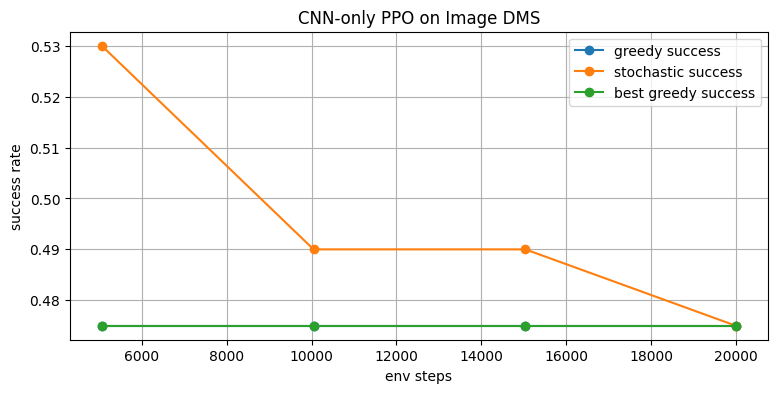

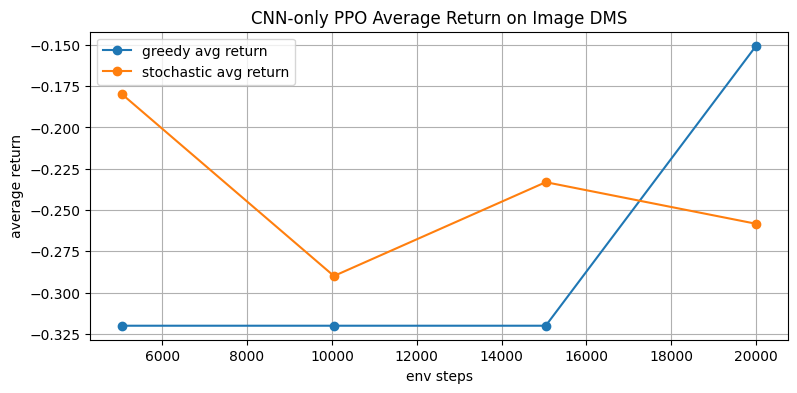

In [23]:
# Colab cell 2: CNN-only PPO baseline

def train_cnn_ppo(total_steps=TOTAL_STEPS):
    env = ImageDelayedMatchToSampleEnv(delay_len=DELAY_LEN, image_size=IMG_SIZE)
    model = CNNActorCritic(env.action_space.n).to(device)
    opt = optim.Adam(model.parameters(), lr=2.5e-4)

    rollout_steps = 64
    ppo_epochs = 4
    clip_coef = 0.2
    vf_coef = 0.5
    ent_coef = 1e-3

    global_step = 0
    best_success = -1.0
    ep_ret = 0.0
    episode_returns = deque(maxlen=50)

    obs, _ = env.reset(seed=SEED)

    metrics = {
        "steps": [],
        "success_greedy": [],
        "success_stochastic": [],
        "avg_return_greedy": [],
        "avg_return_stochastic": [],
        "best_success_greedy": [],
    }

    while global_step < total_steps:
        obs_buf, act_buf, logp_buf, rew_buf, done_buf, val_buf = [], [], [], [], [], []

        for _ in range(rollout_steps):
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                logits, value = model(obs_t)
                dist = Categorical(logits=logits)
                action = dist.sample()
                logp = dist.log_prob(action)

            next_obs, reward, term, trunc, info = env.step(action.item())
            done = term or trunc

            obs_buf.append(obs_t.squeeze(0))
            act_buf.append(action.squeeze(0) if action.ndim > 0 else action)
            logp_buf.append(logp.squeeze(0) if logp.ndim > 0 else logp)
            rew_buf.append(torch.tensor(reward, dtype=torch.float32, device=device))
            done_buf.append(torch.tensor(float(done), dtype=torch.float32, device=device))
            val_buf.append(value.squeeze(0) if value.ndim > 0 else value)

            ep_ret += reward
            global_step += 1
            obs = next_obs

            if done:
                episode_returns.append(ep_ret)
                ep_ret = 0.0
                obs, _ = env.reset()

            if global_step % CHECKPOINT_EVERY == 0:
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(CKPT_DIR, f"image_dms_cnn_ppo_{global_step}.pt"),
                )

            if global_step >= total_steps:
                break

        with torch.no_grad():
            obs_t = to_tensor_obs(obs)
            _, next_value = model(obs_t)

        rewards = torch.stack(rew_buf)
        dones = torch.stack(done_buf)
        values = torch.stack(val_buf)

        adv, ret = compute_gae(rewards, dones, values, next_value.squeeze(0))
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        obs_batch = torch.stack(obs_buf)
        act_batch = torch.stack(act_buf)
        old_logp = torch.stack(logp_buf)

        for _ in range(ppo_epochs):
            logits, new_values = model(obs_batch)
            dist = Categorical(logits=logits)
            new_logp = dist.log_prob(act_batch)
            ent = dist.entropy().mean()

            ratio = (new_logp - old_logp).exp()
            pg1 = -adv * ratio
            pg2 = -adv * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
            policy_loss = torch.max(pg1, pg2).mean()
            value_loss = 0.5 * (ret - new_values).pow(2).mean()
            loss = policy_loss + vf_coef * value_loss - ent_coef * ent

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step()

        if global_step % 5000 < rollout_steps:
            succ_g, avg_ret_g = evaluate_cnn_policy(model, episodes=200, greedy=True, recurrent=False)
            succ_s, avg_ret_s = evaluate_cnn_policy(model, episodes=200, greedy=False, recurrent=False)

            if succ_g > best_success:
                best_success = succ_g
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(CKPT_DIR, "image_dms_cnn_ppo_best.pt"),
                )
                print("⭐ new best CNN-only checkpoint saved")

            metrics["steps"].append(global_step)
            metrics["success_greedy"].append(succ_g)
            metrics["success_stochastic"].append(succ_s)
            metrics["avg_return_greedy"].append(avg_ret_g)
            metrics["avg_return_stochastic"].append(avg_ret_s)
            metrics["best_success_greedy"].append(best_success)

            print(
                f"[Image DMS CNN-only PPO] step {global_step:6d} | "
                f"greedy success {succ_g:.3f} | greedy avg_ret {avg_ret_g:.3f} | "
                f"stoch success {succ_s:.3f} | stoch avg_ret {avg_ret_s:.3f} | "
                f"best greedy {best_success:.3f}",
                flush=True,
            )

    env.close()
    return model, metrics


cnn_only_model, cnn_only_metrics = train_cnn_ppo(TOTAL_STEPS)

plt.figure(figsize=(9, 4))
plt.plot(cnn_only_metrics["steps"], cnn_only_metrics["success_greedy"], marker="o", label="greedy success")
plt.plot(cnn_only_metrics["steps"], cnn_only_metrics["success_stochastic"], marker="o", label="stochastic success")
plt.plot(cnn_only_metrics["steps"], cnn_only_metrics["best_success_greedy"], marker="o", label="best greedy success")
plt.xlabel("env steps")
plt.ylabel("success rate")
plt.title("CNN-only PPO on Image DMS")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(cnn_only_metrics["steps"], cnn_only_metrics["avg_return_greedy"], marker="o", label="greedy avg return")
plt.plot(cnn_only_metrics["steps"], cnn_only_metrics["avg_return_stochastic"], marker="o", label="stochastic avg return")
plt.xlabel("env steps")
plt.ylabel("average return")
plt.title("CNN-only PPO Average Return on Image DMS")
plt.legend()
plt.grid(True)
plt.show()

cnn_only_video = os.path.join(VID_DIR, "image_dms_cnn_only_greedy.mp4")
make_video_cnn_policy(cnn_only_model, cnn_only_video, episodes=3, recurrent=False)
display(Video(cnn_only_video, embed=True, width=360))

⭐ new best CNN+LSTM checkpoint saved
[Image DMS CNN+LSTM PPO] step   5056 | greedy success 0.475 | greedy avg_ret -0.250 | stoch success 0.495 | stoch avg_ret -0.212 | best greedy 0.475
⭐ new best CNN+LSTM checkpoint saved
[Image DMS CNN+LSTM PPO] step  10048 | greedy success 1.000 | greedy avg_ret 0.910 | stoch success 0.555 | stoch avg_ret -0.041 | best greedy 1.000
[Image DMS CNN+LSTM PPO] step  15040 | greedy success 1.000 | greedy avg_ret 0.910 | stoch success 0.965 | stoch avg_ret 0.822 | best greedy 1.000
[Image DMS CNN+LSTM PPO] step  20000 | greedy success 1.000 | greedy avg_ret 0.910 | stoch success 0.955 | stoch avg_ret 0.813 | best greedy 1.000


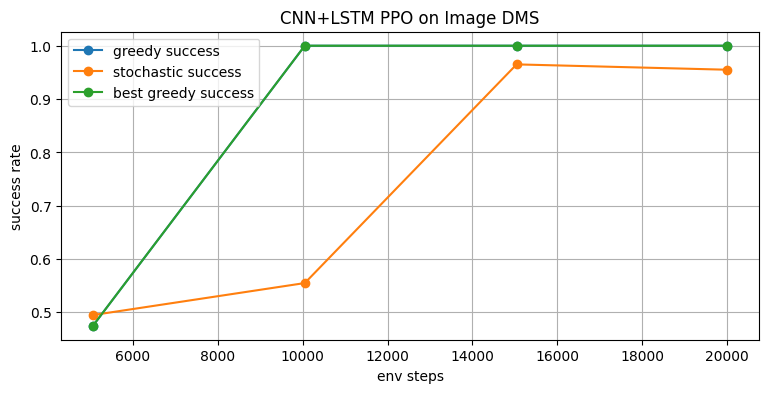

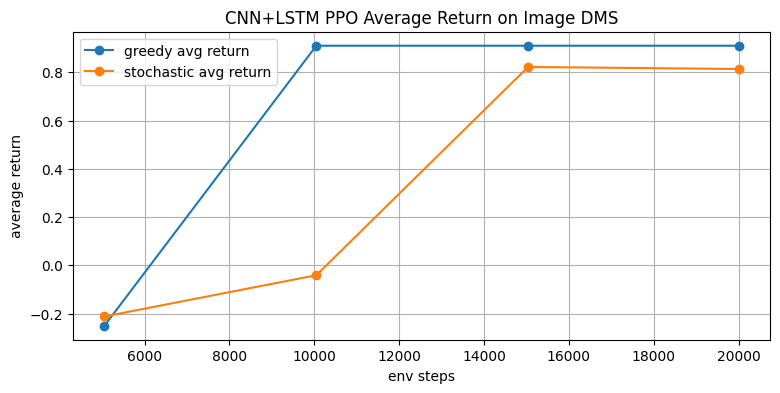

In [24]:
# Colab cell 3: CNN + LSTM PPO

def train_cnn_lstm_ppo(total_steps=TOTAL_STEPS):
    env = ImageDelayedMatchToSampleEnv(delay_len=DELAY_LEN, image_size=IMG_SIZE)
    model = CNNLSTMActorCritic(env.action_space.n, lstm_hidden=128).to(device)
    opt = optim.Adam(model.parameters(), lr=1e-4)

    rollout_steps = 64
    ppo_epochs = 4
    clip_coef = 0.2
    vf_coef = 0.5
    ent_coef = 1e-3

    global_step = 0
    best_success = -1.0
    ep_ret = 0.0
    episode_returns = deque(maxlen=50)

    obs, _ = env.reset(seed=SEED)
    hidden = model.init_hidden(1)

    metrics = {
        "steps": [],
        "success_greedy": [],
        "success_stochastic": [],
        "avg_return_greedy": [],
        "avg_return_stochastic": [],
        "best_success_greedy": [],
    }

    while global_step < total_steps:
        obs_buf, act_buf, logp_buf, rew_buf, done_buf, val_buf = [], [], [], [], [], []
        hidden0 = (hidden[0].detach().clone(), hidden[1].detach().clone())

        for _ in range(rollout_steps):
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                action, logp, ent, value, hidden = model.step(obs_t, hidden)

            next_obs, reward, term, trunc, info = env.step(action.item())
            done = term or trunc

            obs_buf.append(obs_t.squeeze(0))
            act_buf.append(action.squeeze(0) if action.ndim > 0 else action)
            logp_buf.append(logp.squeeze(0) if logp.ndim > 0 else logp)
            rew_buf.append(torch.tensor(reward, dtype=torch.float32, device=device))
            done_buf.append(torch.tensor(float(done), dtype=torch.float32, device=device))
            val_buf.append(value.squeeze(0) if value.ndim > 0 else value)

            ep_ret += reward
            global_step += 1
            obs = next_obs

            if done:
                episode_returns.append(ep_ret)
                ep_ret = 0.0
                obs, _ = env.reset()
                hidden = model.init_hidden(1)
            else:
                hidden = (hidden[0].detach(), hidden[1].detach())

            if global_step % CHECKPOINT_EVERY == 0:
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(CKPT_DIR, f"image_dms_cnn_lstm_ppo_{global_step}.pt"),
                )

            if global_step >= total_steps:
                break

        with torch.no_grad():
            obs_t = to_tensor_obs(obs)
            _, _, _, next_value, _ = model.step(obs_t, hidden)

        rewards = torch.stack(rew_buf)
        dones = torch.stack(done_buf)
        values = torch.stack(val_buf)

        adv, ret = compute_gae(rewards, dones, values, next_value.squeeze(0))
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        obs_seq = torch.stack(obs_buf).unsqueeze(1)   # [T,1,C,H,W]
        act_seq = torch.stack(act_buf).view(-1, 1)
        old_logp = torch.stack(logp_buf).view(-1, 1)
        adv_seq = adv.view(-1, 1)
        ret_seq = ret.view(-1, 1)

        for _ in range(ppo_epochs):
            new_logp, ent, new_values = model.evaluate_seq(obs_seq, act_seq, hidden0)

            ratio = (new_logp - old_logp).exp()
            pg1 = -adv_seq * ratio
            pg2 = -adv_seq * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
            policy_loss = torch.max(pg1, pg2).mean()
            value_loss = 0.5 * (ret_seq - new_values).pow(2).mean()
            ent_loss = ent.mean()
            loss = policy_loss + vf_coef * value_loss - ent_coef * ent_loss

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step()

        if global_step % 5000 < rollout_steps:
            succ_g, avg_ret_g = evaluate_cnn_policy(model, episodes=200, greedy=True, recurrent=True)
            succ_s, avg_ret_s = evaluate_cnn_policy(model, episodes=200, greedy=False, recurrent=True)

            if succ_g > best_success:
                best_success = succ_g
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(CKPT_DIR, "image_dms_cnn_lstm_ppo_best.pt"),
                )
                print("⭐ new best CNN+LSTM checkpoint saved")

            metrics["steps"].append(global_step)
            metrics["success_greedy"].append(succ_g)
            metrics["success_stochastic"].append(succ_s)
            metrics["avg_return_greedy"].append(avg_ret_g)
            metrics["avg_return_stochastic"].append(avg_ret_s)
            metrics["best_success_greedy"].append(best_success)

            print(
                f"[Image DMS CNN+LSTM PPO] step {global_step:6d} | "
                f"greedy success {succ_g:.3f} | greedy avg_ret {avg_ret_g:.3f} | "
                f"stoch success {succ_s:.3f} | stoch avg_ret {avg_ret_s:.3f} | "
                f"best greedy {best_success:.3f}",
                flush=True,
            )

    env.close()
    return model, metrics


cnn_lstm_model, cnn_lstm_metrics = train_cnn_lstm_ppo(TOTAL_STEPS)

plt.figure(figsize=(9, 4))
plt.plot(cnn_lstm_metrics["steps"], cnn_lstm_metrics["success_greedy"], marker="o", label="greedy success")
plt.plot(cnn_lstm_metrics["steps"], cnn_lstm_metrics["success_stochastic"], marker="o", label="stochastic success")
plt.plot(cnn_lstm_metrics["steps"], cnn_lstm_metrics["best_success_greedy"], marker="o", label="best greedy success")
plt.xlabel("env steps")
plt.ylabel("success rate")
plt.title("CNN+LSTM PPO on Image DMS")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(cnn_lstm_metrics["steps"], cnn_lstm_metrics["avg_return_greedy"], marker="o", label="greedy avg return")
plt.plot(cnn_lstm_metrics["steps"], cnn_lstm_metrics["avg_return_stochastic"], marker="o", label="stochastic avg return")
plt.xlabel("env steps")
plt.ylabel("average return")
plt.title("CNN+LSTM PPO Average Return on Image DMS")
plt.legend()
plt.grid(True)
plt.show()

cnn_lstm_video = os.path.join(VID_DIR, "image_dms_cnn_lstm_greedy.mp4")
make_video_cnn_policy(cnn_lstm_model, cnn_lstm_video, episodes=3, recurrent=True)
display(Video(cnn_lstm_video, embed=True, width=360))

In [25]:
# Colab cell 1: Symbolic T-Maze + MLP-only PPO

!pip -q install gymnasium matplotlib

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

TOTAL_STEPS = 100_000
CHECKPOINT_EVERY = 50_000
OUT_DIR = "/content/symbolic_tmaze_compare"
os.makedirs(OUT_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


class SymbolicTMazeEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self, corridor_length=3, max_steps=None, render_mode=None):
        super().__init__()
        self.corridor_length = corridor_length
        self.max_steps = max_steps if max_steps is not None else corridor_length + 3
        self.render_mode = render_mode

        self.action_space = spaces.Discrete(3)  # 0=forward, 1=left, 2=right
        self.observation_space = spaces.Box(
            low=np.array([0.0, -1.0, 0.0], dtype=np.float32),
            high=np.array([1.0,  1.0, 1.0], dtype=np.float32),
            dtype=np.float32,
        )

        self.pos = 0
        self.cue = 0
        self.done = False
        self.steps = 0

    def _get_obs(self):
        pos_norm = self.pos / self.corridor_length
        cue_val = float(self.cue) if self.pos == 0 else 0.0
        at_junction = 1.0 if self.pos == self.corridor_length else 0.0
        return np.array([pos_norm, cue_val, at_junction], dtype=np.float32)

    def _get_info(self, success=False):
        return {"pos": self.pos, "cue": int(self.cue), "success": bool(success)}

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.pos = 0
        self.done = False
        self.steps = 0
        self.cue = int(self.np_random.choice([-1, 1]))  # -1=left, +1=right
        return self._get_obs(), self._get_info(success=False)

    def step(self, action):
        if self.done:
            raise RuntimeError("Episode done. Call reset().")

        self.steps += 1
        reward = -0.01
        terminated = False
        truncated = False
        success = False

        if self.pos < self.corridor_length:
            if action == 0:
                self.pos += 1
                reward += 0.05
            else:
                reward -= 0.02
        else:
            if action == 1:
                reward = 10.0 if self.cue == -1 else -10.0
                success = (self.cue == -1)
                terminated = True
                self.done = True
            elif action == 2:
                reward = 10.0 if self.cue == 1 else -10.0
                success = (self.cue == 1)
                terminated = True
                self.done = True
            else:
                reward = -1.0
                terminated = True
                self.done = True

        if self.steps >= self.max_steps and not terminated:
            truncated = True
            self.done = True

        return self._get_obs(), reward, terminated, truncated, self._get_info(success=success)


class MLPActorCritic(nn.Module):
    def __init__(self, obs_dim, num_actions, hidden_dim=64):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
        self.pi = nn.Linear(hidden_dim, num_actions)
        self.v = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        z = self.body(x)
        logits = self.pi(z)
        value = self.v(z).squeeze(-1)
        return logits, value


def to_tensor_obs(obs):
    return torch.from_numpy(np.asarray(obs, dtype=np.float32)).unsqueeze(0).to(device)


def compute_gae(rewards, dones, values, next_value, gamma=0.99, lam=0.95):
    T = len(rewards)
    adv = torch.zeros(T, device=device)
    last = 0.0
    for t in reversed(range(T)):
        if t == T - 1:
            next_nonterminal = 1.0 - dones[t]
            next_values = next_value
        else:
            next_nonterminal = 1.0 - dones[t]
            next_values = values[t + 1]
        delta = rewards[t] + gamma * next_values * next_nonterminal - values[t]
        last = delta + gamma * lam * next_nonterminal * last
        adv[t] = last
    ret = adv + values
    return adv, ret


def evaluate_mlp_policy(model, episodes=200, greedy=True):
    env = SymbolicTMazeEnv(corridor_length=3)
    success = 0
    ret_sum = 0.0

    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + 10000 + ep)
        done = False
        ep_ret = 0.0
        final_success = False

        while not done:
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                logits, _ = model(obs_t)
                if greedy:
                    action = torch.argmax(logits, dim=-1).item()
                else:
                    dist = Categorical(logits=logits)
                    action = dist.sample().item()

            obs, reward, term, trunc, info = env.step(action)
            ep_ret += reward
            final_success = info["success"]
            done = term or trunc

        ret_sum += ep_ret
        if final_success:
            success += 1

    env.close()
    return success / episodes, ret_sum / episodes


def train_mlp_ppo(total_steps=100_000):
    env = SymbolicTMazeEnv(corridor_length=3)
    model = MLPActorCritic(obs_dim=3, num_actions=env.action_space.n, hidden_dim=64).to(device)
    opt = optim.Adam(model.parameters(), lr=3e-4)

    rollout_steps = 64
    ppo_epochs = 4
    clip_coef = 0.2
    vf_coef = 0.5
    ent_coef = 1e-3

    global_step = 0
    best_success = -1.0
    ep_ret = 0.0
    episode_returns = deque(maxlen=50)

    obs, _ = env.reset(seed=SEED)

    metrics = {
        "steps": [],
        "success_greedy": [],
        "success_stochastic": [],
        "avg_return_greedy": [],
        "avg_return_stochastic": [],
        "best_success_greedy": [],
    }

    while global_step < total_steps:
        obs_buf, act_buf, logp_buf, rew_buf, done_buf, val_buf = [], [], [], [], [], []

        for _ in range(rollout_steps):
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                logits, value = model(obs_t)
                dist = Categorical(logits=logits)
                action = dist.sample()
                logp = dist.log_prob(action)

            next_obs, reward, term, trunc, info = env.step(action.item())
            done = term or trunc

            obs_buf.append(obs_t.squeeze(0))
            act_buf.append(action.squeeze(0) if action.ndim > 0 else action)
            logp_buf.append(logp.squeeze(0) if logp.ndim > 0 else logp)
            rew_buf.append(torch.tensor(reward, dtype=torch.float32, device=device))
            done_buf.append(torch.tensor(float(done), dtype=torch.float32, device=device))
            val_buf.append(value.squeeze(0) if value.ndim > 0 else value)

            ep_ret += reward
            global_step += 1
            obs = next_obs

            if done:
                episode_returns.append(ep_ret)
                ep_ret = 0.0
                obs, _ = env.reset()

            if global_step % CHECKPOINT_EVERY == 0:
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(OUT_DIR, f"symbolic_tmaze_mlp_ppo_{global_step}.pt"),
                )

            if global_step >= total_steps:
                break

        with torch.no_grad():
            obs_t = to_tensor_obs(obs)
            _, next_value = model(obs_t)

        rewards = torch.stack(rew_buf)
        dones = torch.stack(done_buf)
        values = torch.stack(val_buf)

        adv, ret = compute_gae(rewards, dones, values, next_value.squeeze(0))
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        obs_batch = torch.stack(obs_buf)
        act_batch = torch.stack(act_buf)
        old_logp = torch.stack(logp_buf)

        for _ in range(ppo_epochs):
            logits, new_values = model(obs_batch)
            dist = Categorical(logits=logits)
            new_logp = dist.log_prob(act_batch)
            ent = dist.entropy().mean()

            ratio = (new_logp - old_logp).exp()
            pg1 = -adv * ratio
            pg2 = -adv * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
            policy_loss = torch.max(pg1, pg2).mean()
            value_loss = 0.5 * (ret - new_values).pow(2).mean()
            loss = policy_loss + vf_coef * value_loss - ent_coef * ent

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step()

        if global_step % 5000 < rollout_steps:
            succ_g, avg_ret_g = evaluate_mlp_policy(model, episodes=200, greedy=True)
            succ_s, avg_ret_s = evaluate_mlp_policy(model, episodes=200, greedy=False)

            if succ_g > best_success:
                best_success = succ_g
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(OUT_DIR, "symbolic_tmaze_mlp_ppo_best.pt"),
                )
                print("⭐ new best MLP-only checkpoint saved")

            metrics["steps"].append(global_step)
            metrics["success_greedy"].append(succ_g)
            metrics["success_stochastic"].append(succ_s)
            metrics["avg_return_greedy"].append(avg_ret_g)
            metrics["avg_return_stochastic"].append(avg_ret_s)
            metrics["best_success_greedy"].append(best_success)

            print(
                f"[Symbolic T-Maze MLP-only PPO] step {global_step:6d} | "
                f"greedy success {succ_g:.3f} | greedy avg_ret {avg_ret_g:.3f} | "
                f"stoch success {succ_s:.3f} | stoch avg_ret {avg_ret_s:.3f} | "
                f"best greedy {best_success:.3f}",
                flush=True,
            )

    env.close()
    return model, metrics


mlp_model, mlp_metrics = train_mlp_ppo(TOTAL_STEPS)

plt.figure(figsize=(9, 4))
plt.plot(mlp_metrics["steps"], mlp_metrics["success_greedy"], marker="o", label="greedy success")
plt.plot(mlp_metrics["steps"], mlp_metrics["success_stochastic"], marker="o", label="stochastic success")
plt.plot(mlp_metrics["steps"], mlp_metrics["best_success_greedy"], marker="o", label="best greedy success")
plt.xlabel("env steps")
plt.ylabel("success rate")
plt.title("MLP-only PPO on Symbolic T-Maze")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(mlp_metrics["steps"], mlp_metrics["avg_return_greedy"], marker="o", label="greedy avg return")
plt.plot(mlp_metrics["steps"], mlp_metrics["avg_return_stochastic"], marker="o", label="stochastic avg return")
plt.xlabel("env steps")
plt.ylabel("average return")
plt.title("Average Return on Symbolic T-Maze")
plt.legend()
plt.grid(True)
plt.show()

device: cuda
gpu: Tesla T4
⭐ new best MLP-only checkpoint saved
[Symbolic T-Maze MLP-only PPO] step   5056 | greedy success 0.000 | greedy avg_ret -0.106 | stoch success 0.190 | stoch avg_ret 0.658 | best greedy 0.000
⭐ new best MLP-only checkpoint saved
[Symbolic T-Maze MLP-only PPO] step  10048 | greedy success 0.525 | greedy avg_ret 5.228 | stoch success 0.300 | stoch avg_ret 2.184 | best greedy 0.525
[Symbolic T-Maze MLP-only PPO] step  15040 | greedy success 0.525 | greedy avg_ret 5.228 | stoch success 0.465 | stoch avg_ret 4.261 | best greedy 0.525
[Symbolic T-Maze MLP-only PPO] step  20032 | greedy success 0.525 | greedy avg_ret 5.228 | stoch success 0.485 | stoch avg_ret 4.471 | best greedy 0.525
[Symbolic T-Maze MLP-only PPO] step  25024 | greedy success 0.525 | greedy avg_ret 5.228 | stoch success 0.500 | stoch avg_ret 4.707 | best greedy 0.525
[Symbolic T-Maze MLP-only PPO] step  30016 | greedy success 0.525 | greedy avg_ret 5.228 | stoch success 0.500 | stoch avg_ret 4.709 

KeyboardInterrupt: 

device: cuda
gpu: Tesla T4
⭐ new best PPO+LSTM checkpoint saved
[Symbolic T-Maze PPO+LSTM] step   5056 | greedy success 0.000 | greedy avg_ret -0.106 | stoch success 0.045 | stoch avg_ret -0.313 | best greedy 0.000
[Symbolic T-Maze PPO+LSTM] step  10048 | greedy success 0.000 | greedy avg_ret -0.180 | stoch success 0.055 | stoch avg_ret -0.173 | best greedy 0.000
[Symbolic T-Maze PPO+LSTM] step  15040 | greedy success 0.000 | greedy avg_ret -0.180 | stoch success 0.045 | stoch avg_ret 0.046 | best greedy 0.000
[Symbolic T-Maze PPO+LSTM] step  20032 | greedy success 0.000 | greedy avg_ret -0.180 | stoch success 0.055 | stoch avg_ret -0.194 | best greedy 0.000
[Symbolic T-Maze PPO+LSTM] step  25024 | greedy success 0.000 | greedy avg_ret -0.147 | stoch success 0.100 | stoch avg_ret 0.076 | best greedy 0.000
[Symbolic T-Maze PPO+LSTM] step  30016 | greedy success 0.000 | greedy avg_ret -0.113 | stoch success 0.105 | stoch avg_ret 0.303 | best greedy 0.000
[Symbolic T-Maze PPO+LSTM] step  

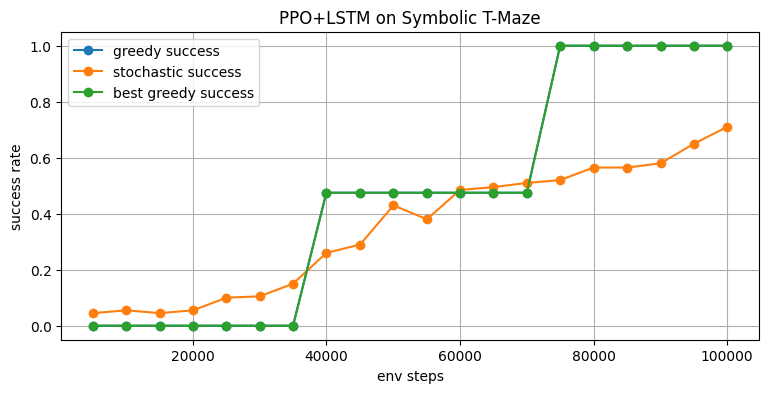

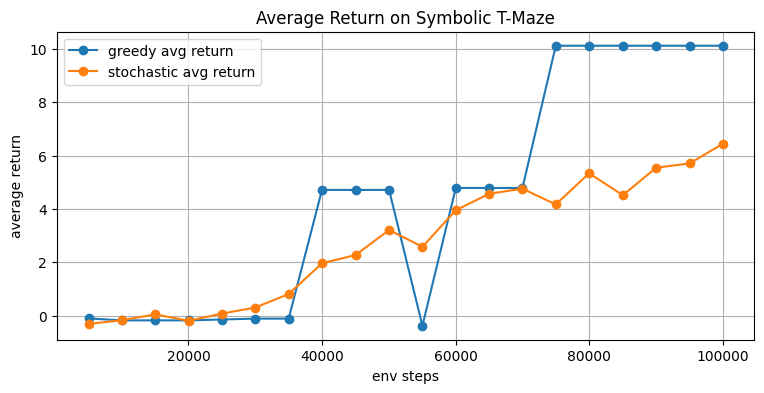

In [26]:
# Colab cell 2: Symbolic T-Maze + PPO + LSTM

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

TOTAL_STEPS = 100_000
CHECKPOINT_EVERY = 50_000
OUT_DIR = "/content/symbolic_tmaze_compare"
os.makedirs(OUT_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


class SymbolicTMazeEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self, corridor_length=3, max_steps=None, render_mode=None):
        super().__init__()
        self.corridor_length = corridor_length
        self.max_steps = max_steps if max_steps is not None else corridor_length + 3
        self.render_mode = render_mode

        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(
            low=np.array([0.0, -1.0, 0.0], dtype=np.float32),
            high=np.array([1.0,  1.0, 1.0], dtype=np.float32),
            dtype=np.float32,
        )

        self.pos = 0
        self.cue = 0
        self.done = False
        self.steps = 0

    def _get_obs(self):
        pos_norm = self.pos / self.corridor_length
        cue_val = float(self.cue) if self.pos == 0 else 0.0
        at_junction = 1.0 if self.pos == self.corridor_length else 0.0
        return np.array([pos_norm, cue_val, at_junction], dtype=np.float32)

    def _get_info(self, success=False):
        return {"pos": self.pos, "cue": int(self.cue), "success": bool(success)}

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.pos = 0
        self.done = False
        self.steps = 0
        self.cue = int(self.np_random.choice([-1, 1]))
        return self._get_obs(), self._get_info(success=False)

    def step(self, action):
        if self.done:
            raise RuntimeError("Episode done. Call reset().")

        self.steps += 1
        reward = -0.01
        terminated = False
        truncated = False
        success = False

        if self.pos < self.corridor_length:
            if action == 0:
                self.pos += 1
                reward += 0.05
            else:
                reward -= 0.02
        else:
            if action == 1:
                reward = 10.0 if self.cue == -1 else -10.0
                success = (self.cue == -1)
                terminated = True
                self.done = True
            elif action == 2:
                reward = 10.0 if self.cue == 1 else -10.0
                success = (self.cue == 1)
                terminated = True
                self.done = True
            else:
                reward = -1.0
                terminated = True
                self.done = True

        if self.steps >= self.max_steps and not terminated:
            truncated = True
            self.done = True

        return self._get_obs(), reward, terminated, truncated, self._get_info(success=success)


class MLPLSTMActorCritic(nn.Module):
    def __init__(self, obs_dim, num_actions, hidden_dim=64, lstm_hidden=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
        self.lstm = nn.LSTM(hidden_dim, lstm_hidden, num_layers=1)
        self.pi = nn.Linear(lstm_hidden, num_actions)
        self.v = nn.Linear(lstm_hidden, 1)
        self.lstm_hidden = lstm_hidden

    def init_hidden(self, batch_size=1):
        h = torch.zeros(1, batch_size, self.lstm_hidden, device=device)
        c = torch.zeros(1, batch_size, self.lstm_hidden, device=device)
        return (h, c)

    def step(self, x, hidden):
        z = self.mlp(x).unsqueeze(0)
        out, hidden = self.lstm(z, hidden)
        out = out.squeeze(0)
        logits = self.pi(out)
        value = self.v(out).squeeze(-1)
        dist = Categorical(logits=logits)
        action = dist.sample()
        logp = dist.log_prob(action)
        ent = dist.entropy()
        return action, logp, ent, value, hidden

    def greedy_step(self, x, hidden):
        z = self.mlp(x).unsqueeze(0)
        out, hidden = self.lstm(z, hidden)
        out = out.squeeze(0)
        logits = self.pi(out)
        value = self.v(out).squeeze(-1)
        action = torch.argmax(logits, dim=-1)
        return action, value, hidden

    def evaluate_seq(self, obs_seq, act_seq, hidden0):
        T, B, D = obs_seq.shape
        x = obs_seq.reshape(T * B, D)
        z = self.mlp(x).view(T, B, -1)
        out, _ = self.lstm(z, hidden0)
        logits = self.pi(out)
        values = self.v(out).squeeze(-1)
        dist = Categorical(logits=logits)
        logp = dist.log_prob(act_seq)
        ent = dist.entropy()
        return logp, ent, values


def to_tensor_obs(obs):
    return torch.from_numpy(np.asarray(obs, dtype=np.float32)).unsqueeze(0).to(device)


def compute_gae(rewards, dones, values, next_value, gamma=0.99, lam=0.95):
    T = len(rewards)
    adv = torch.zeros(T, device=device)
    last = 0.0
    for t in reversed(range(T)):
        if t == T - 1:
            next_nonterminal = 1.0 - dones[t]
            next_values = next_value
        else:
            next_nonterminal = 1.0 - dones[t]
            next_values = values[t + 1]
        delta = rewards[t] + gamma * next_values * next_nonterminal - values[t]
        last = delta + gamma * lam * next_nonterminal * last
        adv[t] = last
    ret = adv + values
    return adv, ret


def evaluate_lstm_policy(model, episodes=200, greedy=True):
    env = SymbolicTMazeEnv(corridor_length=3)
    success = 0
    ret_sum = 0.0

    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + 10000 + ep)
        done = False
        ep_ret = 0.0
        final_success = False
        hidden = model.init_hidden(1)

        while not done:
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                if greedy:
                    action, _, hidden = model.greedy_step(obs_t, hidden)
                    action = action.item()
                else:
                    action, _, _, _, hidden = model.step(obs_t, hidden)
                    action = action.item()

            obs, reward, term, trunc, info = env.step(action)
            ep_ret += reward
            final_success = info["success"]
            done = term or trunc

        ret_sum += ep_ret
        if final_success:
            success += 1

    env.close()
    return success / episodes, ret_sum / episodes


def train_lstm_ppo(total_steps=100_000):
    env = SymbolicTMazeEnv(corridor_length=3)
    model = MLPLSTMActorCritic(obs_dim=3, num_actions=env.action_space.n, hidden_dim=64, lstm_hidden=64).to(device)
    opt = optim.Adam(model.parameters(), lr=1e-4)

    rollout_steps = 64
    ppo_epochs = 4
    clip_coef = 0.2
    vf_coef = 0.5
    ent_coef = 1e-3

    global_step = 0
    best_success = -1.0
    ep_ret = 0.0
    episode_returns = deque(maxlen=50)

    obs, _ = env.reset(seed=SEED)
    hidden = model.init_hidden(1)

    metrics = {
        "steps": [],
        "success_greedy": [],
        "success_stochastic": [],
        "avg_return_greedy": [],
        "avg_return_stochastic": [],
        "best_success_greedy": [],
    }

    while global_step < total_steps:
        obs_buf, act_buf, logp_buf, rew_buf, done_buf, val_buf = [], [], [], [], [], []
        hidden0 = (hidden[0].detach().clone(), hidden[1].detach().clone())

        for _ in range(rollout_steps):
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                action, logp, ent, value, hidden = model.step(obs_t, hidden)

            next_obs, reward, term, trunc, info = env.step(action.item())
            done = term or trunc

            obs_buf.append(obs_t.squeeze(0))
            act_buf.append(action.squeeze(0) if action.ndim > 0 else action)
            logp_buf.append(logp.squeeze(0) if logp.ndim > 0 else logp)
            rew_buf.append(torch.tensor(reward, dtype=torch.float32, device=device))
            done_buf.append(torch.tensor(float(done), dtype=torch.float32, device=device))
            val_buf.append(value.squeeze(0) if value.ndim > 0 else value)

            ep_ret += reward
            global_step += 1
            obs = next_obs

            if done:
                episode_returns.append(ep_ret)
                ep_ret = 0.0
                obs, _ = env.reset()
                hidden = model.init_hidden(1)
            else:
                hidden = (hidden[0].detach(), hidden[1].detach())

            if global_step % CHECKPOINT_EVERY == 0:
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(OUT_DIR, f"symbolic_tmaze_lstm_ppo_{global_step}.pt"),
                )

            if global_step >= total_steps:
                break

        with torch.no_grad():
            obs_t = to_tensor_obs(obs)
            _, _, _, next_value, _ = model.step(obs_t, hidden)

        rewards = torch.stack(rew_buf)
        dones = torch.stack(done_buf)
        values = torch.stack(val_buf)

        adv, ret = compute_gae(rewards, dones, values, next_value.squeeze(0))
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        obs_seq = torch.stack(obs_buf).unsqueeze(1)
        act_seq = torch.stack(act_buf).view(-1, 1)
        old_logp = torch.stack(logp_buf).view(-1, 1)
        adv_seq = adv.view(-1, 1)
        ret_seq = ret.view(-1, 1)

        for _ in range(ppo_epochs):
            new_logp, ent, new_values = model.evaluate_seq(obs_seq, act_seq, hidden0)

            ratio = (new_logp - old_logp).exp()
            pg1 = -adv_seq * ratio
            pg2 = -adv_seq * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
            policy_loss = torch.max(pg1, pg2).mean()
            value_loss = 0.5 * (ret_seq - new_values).pow(2).mean()
            ent_loss = ent.mean()
            loss = policy_loss + vf_coef * value_loss - ent_coef * ent_loss

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step()

        if global_step % 5000 < rollout_steps:
            succ_g, avg_ret_g = evaluate_lstm_policy(model, episodes=200, greedy=True)
            succ_s, avg_ret_s = evaluate_lstm_policy(model, episodes=200, greedy=False)

            if succ_g > best_success:
                best_success = succ_g
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(OUT_DIR, "symbolic_tmaze_lstm_ppo_best.pt"),
                )
                print("⭐ new best PPO+LSTM checkpoint saved")

            metrics["steps"].append(global_step)
            metrics["success_greedy"].append(succ_g)
            metrics["success_stochastic"].append(succ_s)
            metrics["avg_return_greedy"].append(avg_ret_g)
            metrics["avg_return_stochastic"].append(avg_ret_s)
            metrics["best_success_greedy"].append(best_success)

            print(
                f"[Symbolic T-Maze PPO+LSTM] step {global_step:6d} | "
                f"greedy success {succ_g:.3f} | greedy avg_ret {avg_ret_g:.3f} | "
                f"stoch success {succ_s:.3f} | stoch avg_ret {avg_ret_s:.3f} | "
                f"best greedy {best_success:.3f}",
                flush=True,
            )

    env.close()
    return model, metrics


lstm_model, lstm_metrics = train_lstm_ppo(TOTAL_STEPS)

plt.figure(figsize=(9, 4))
plt.plot(lstm_metrics["steps"], lstm_metrics["success_greedy"], marker="o", label="greedy success")
plt.plot(lstm_metrics["steps"], lstm_metrics["success_stochastic"], marker="o", label="stochastic success")
plt.plot(lstm_metrics["steps"], lstm_metrics["best_success_greedy"], marker="o", label="best greedy success")
plt.xlabel("env steps")
plt.ylabel("success rate")
plt.title("PPO+LSTM on Symbolic T-Maze")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(lstm_metrics["steps"], lstm_metrics["avg_return_greedy"], marker="o", label="greedy avg return")
plt.plot(lstm_metrics["steps"], lstm_metrics["avg_return_stochastic"], marker="o", label="stochastic avg return")
plt.xlabel("env steps")
plt.ylabel("average return")
plt.title("Average Return on Symbolic T-Maze")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Colab cell 1: Image T-Maze env + shared models/helpers

!pip -q install gymnasium matplotlib imageio imageio-ffmpeg pillow

import os
import random
import imageio
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from IPython.display import Video, display

SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

OUT_DIR = "/content/image_tmaze_compare"
CKPT_DIR = os.path.join(OUT_DIR, "checkpoints")
VID_DIR = os.path.join(OUT_DIR, "videos")
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(VID_DIR, exist_ok=True)

IMG_SIZE = 64
LOCAL_VIEW = 5
CORRIDOR_LEN = 3
MAX_EP_STEPS = CORRIDOR_LEN + 3
CHECKPOINT_EVERY = 100_000
TOTAL_STEPS = 400_000

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


class ImageTMaze3ActionEnv(gym.Env):
    """
    3-action image T-Maze
      0 = forward
      1 = left
      2 = right

    Cue is shown only at start:
      red = left is correct
      yellow = right is correct
    """
    metadata = {"render_modes": ["rgb_array"]}

    def __init__(
        self,
        corridor_length=3,
        view_size=5,
        image_size=64,
        max_steps=6,
        render_mode="rgb_array",
    ):
        super().__init__()
        assert view_size % 2 == 1

        self.corridor_length = corridor_length
        self.view_size = view_size
        self.image_size = image_size
        self.max_steps = max_steps
        self.show_cue_steps = 2
        self.render_mode = render_mode

        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(3, image_size, image_size), dtype=np.float32
        )

        self.height = corridor_length + 2
        self.width = 3
        self._build_maze()

        self.agent_pos = None
        self.cue = None
        self.steps = 0
        self.done = False

    def _build_maze(self):
        self.maze = np.zeros((self.height, self.width), dtype=np.int32)
        self.maze[1:self.height - 1, 1] = 1
        self.maze[self.height - 2, 0] = 1
        self.maze[self.height - 2, 1] = 1
        self.maze[self.height - 2, 2] = 1

        self.start_pos = (1, 1)
        self.left_goal = (self.height - 2, 0)
        self.right_goal = (self.height - 2, 2)
        self.junction = (self.height - 2, 1)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.agent_pos = self.start_pos
        self.cue = self.np_random.choice([-1, 1])  # -1 = left, +1 = right
        self.steps = 0
        self.done = False
        return self._get_obs(), self._get_info(success=False)

    def _get_info(self, success=False):
        return {
            "cue": int(self.cue),
            "agent_pos": self.agent_pos,
            "junction": self.agent_pos == self.junction,
            "success": bool(success),
        }

    def step(self, action):
        if self.done:
            raise RuntimeError("Episode done. Call reset().")

        self.steps += 1
        reward = -0.005
        terminated = False
        truncated = False
        success = False

        if self.agent_pos != self.junction:
            if action == 0:  # forward
                r, c = self.agent_pos
                nr, nc = r + 1, c
                if self._is_free(nr, nc):
                    self.agent_pos = (nr, nc)
                    reward += 0.1
            else:
                reward -= 0.02
        else:
            if action == 1:
                self.agent_pos = self.left_goal
            elif action == 2:
                self.agent_pos = self.right_goal
            else:
                reward = -1.0
                terminated = True
                self.done = True

        if self.agent_pos == self.left_goal:
            reward = 10.0 if self.cue == -1 else -10.0
            terminated = True
            self.done = True
            success = (self.cue == -1)
        elif self.agent_pos == self.right_goal:
            reward = 10.0 if self.cue == 1 else -10.0
            terminated = True
            self.done = True
            success = (self.cue == 1)
        elif self.steps >= self.max_steps and not terminated:
            truncated = True
            self.done = True

        return self._get_obs(), reward, terminated, truncated, self._get_info(success=success)

    def _inside(self, r, c):
        return 0 <= r < self.height and 0 <= c < self.width

    def _is_free(self, r, c):
        return self._inside(r, c) and self.maze[r, c] == 1

    def _full_rgb_grid(self):
        img = np.zeros((self.height, self.width, 3), dtype=np.float32)
        img[self.maze == 1] = np.array([1.0, 1.0, 1.0], dtype=np.float32)

        lr, lc = self.left_goal
        rr, rc = self.right_goal
        img[lr, lc] = np.array([0.0, 1.0, 0.0], dtype=np.float32)
        img[rr, rc] = np.array([0.0, 1.0, 0.0], dtype=np.float32)

        if self.agent_pos == self.start_pos:
            if self.cue == -1:
                img[self.maze == 1] = np.array([1.0, 0.6, 0.6], dtype=np.float32)   # red tint
            else:
                img[self.maze == 1] = np.array([1.0, 1.0, 0.4], dtype=np.float32)   # yellow tint

        ar, ac = self.agent_pos
        img[ar, ac] = np.array([0.0, 0.0, 1.0], dtype=np.float32)
        return img

    def _get_obs(self):
        full = self._full_rgb_grid()
        pad = self.view_size // 2
        padded = np.pad(full, ((pad, pad), (pad, pad), (0, 0)), mode="constant", constant_values=0.0)

        ar, ac = self.agent_pos
        ar += pad
        ac += pad
        crop = padded[ar-pad:ar+pad+1, ac-pad:ac+pad+1, :]

        scale = self.image_size // self.view_size
        up = np.repeat(np.repeat(crop, scale, axis=0), scale, axis=1)

        if up.shape[0] != self.image_size or up.shape[1] != self.image_size:
            out = np.zeros((self.image_size, self.image_size, 3), dtype=np.float32)
            h = min(self.image_size, up.shape[0])
            w = min(self.image_size, up.shape[1])
            out[:h, :w] = up[:h, :w]
            up = out

        return np.transpose(up, (2, 0, 1)).astype(np.float32)

    def render(self):
        full = self._full_rgb_grid()
        scale = self.image_size // self.width
        up = np.repeat(np.repeat(full, scale, axis=0), scale, axis=1)
        return (up * 255).astype(np.uint8)


class CNNEncoder(nn.Module):
    def __init__(self, in_ch=3, img_size=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, 8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1), nn.ReLU(),
            nn.Flatten(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, img_size, img_size)
            self.out_dim = self.net(dummy).shape[-1]

    def forward(self, x):
        return self.net(x)


class CNNActorCritic(nn.Module):
    def __init__(self, num_actions):
        super().__init__()
        self.enc = CNNEncoder(3, IMG_SIZE)
        self.fc = nn.Sequential(nn.Linear(self.enc.out_dim, 256), nn.ReLU())
        self.pi = nn.Linear(256, num_actions)
        self.v = nn.Linear(256, 1)

    def forward(self, x):
        z = self.fc(self.enc(x))
        return self.pi(z), self.v(z).squeeze(-1)


class CNNLSTMActorCritic(nn.Module):
    def __init__(self, num_actions, hidden_size=128):
        super().__init__()
        self.enc = CNNEncoder(3, IMG_SIZE)
        self.fc = nn.Sequential(nn.Linear(self.enc.out_dim, 256), nn.ReLU())
        self.lstm = nn.LSTM(256, hidden_size, num_layers=1)
        self.pi = nn.Linear(hidden_size, num_actions)
        self.v = nn.Linear(hidden_size, 1)
        self.hidden_size = hidden_size

    def init_hidden(self, batch_size=1):
        h = torch.zeros(1, batch_size, self.hidden_size, device=device)
        c = torch.zeros(1, batch_size, self.hidden_size, device=device)
        return (h, c)

    def step(self, x, hidden):
        z = self.fc(self.enc(x)).unsqueeze(0)
        out, hidden = self.lstm(z, hidden)
        out = out.squeeze(0)
        logits = self.pi(out)
        value = self.v(out).squeeze(-1)
        dist = Categorical(logits=logits)
        action = dist.sample()
        logp = dist.log_prob(action)
        ent = dist.entropy()
        return action, logp, ent, value, hidden

    def greedy_step(self, x, hidden):
        z = self.fc(self.enc(x)).unsqueeze(0)
        out, hidden = self.lstm(z, hidden)
        out = out.squeeze(0)
        logits = self.pi(out)
        value = self.v(out).squeeze(-1)
        action = torch.argmax(logits, dim=-1)
        return action, value, hidden

    def evaluate_seq(self, obs_seq, act_seq, hidden0):
        T, B = act_seq.shape
        x = obs_seq.reshape(T * B, *obs_seq.shape[2:])
        z = self.fc(self.enc(x)).view(T, B, -1)
        out, _ = self.lstm(z, hidden0)
        logits = self.pi(out)
        values = self.v(out).squeeze(-1)
        dist = Categorical(logits=logits)
        logp = dist.log_prob(act_seq)
        ent = dist.entropy()
        return logp, ent, values


def to_tensor_obs(obs):
    return torch.from_numpy(np.asarray(obs, dtype=np.float32)).unsqueeze(0).to(device)


def compute_gae(rewards, dones, values, next_value, gamma=0.99, lam=0.95):
    T = len(rewards)
    adv = torch.zeros(T, device=device)
    last = 0.0
    for t in reversed(range(T)):
        if t == T - 1:
            next_nonterminal = 1.0 - dones[t]
            next_values = next_value
        else:
            next_nonterminal = 1.0 - dones[t]
            next_values = values[t + 1]
        delta = rewards[t] + gamma * next_values * next_nonterminal - values[t]
        last = delta + gamma * lam * next_nonterminal * last
        adv[t] = last
    ret = adv + values
    return adv, ret


def evaluate_cnn_policy(model, episodes=200, recurrent=False, greedy=True):
    env = ImageTMaze3ActionEnv(
        corridor_length=CORRIDOR_LEN,
        view_size=LOCAL_VIEW,
        image_size=IMG_SIZE,
        max_steps=MAX_EP_STEPS,
    )
    success = 0
    ret_sum = 0.0

    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + 10000 + ep)
        done = False
        ep_ret = 0.0
        final_success = False
        hidden = model.init_hidden(1) if recurrent else None

        while not done:
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                if recurrent:
                    if greedy:
                        action, _, hidden = model.greedy_step(obs_t, hidden)
                        action = action.item()
                    else:
                        action, _, _, _, hidden = model.step(obs_t, hidden)
                        action = action.item()
                else:
                    logits, _ = model(obs_t)
                    if greedy:
                        action = torch.argmax(logits, dim=-1).item()
                    else:
                        dist = Categorical(logits=logits)
                        action = dist.sample().item()

            obs, reward, term, trunc, info = env.step(action)
            ep_ret += reward
            final_success = info["success"]
            done = term or trunc

        ret_sum += ep_ret
        if final_success:
            success += 1

    env.close()
    return success / episodes, ret_sum / episodes


def make_video_cnn_policy(model, path, episodes=3, recurrent=False):
    env = ImageTMaze3ActionEnv(
        corridor_length=CORRIDOR_LEN,
        view_size=LOCAL_VIEW,
        image_size=IMG_SIZE,
        max_steps=MAX_EP_STEPS,
        render_mode="rgb_array",
    )
    frames = []

    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + 3000 + ep)
        done = False
        hidden = model.init_hidden(1) if recurrent else None

        while not done:
            frames.append(env.render())
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                if recurrent:
                    action, _, hidden = model.greedy_step(obs_t, hidden)
                    action = action.item()
                else:
                    logits, _ = model(obs_t)
                    action = torch.argmax(logits, dim=-1).item()

            obs, reward, term, trunc, info = env.step(action)
            done = term or trunc

        for _ in range(8):
            frames.append(env.render())

    with imageio.get_writer(path, fps=4) as writer:
        for f in frames:
            writer.append_data(f)

    env.close()

device: cuda
gpu: Tesla T4


In [28]:
# Colab cell 2: Image T-Maze CNN-only PPO

def train_cnn_ppo(total_steps=TOTAL_STEPS):
    env = ImageTMaze3ActionEnv(
        corridor_length=CORRIDOR_LEN,
        view_size=LOCAL_VIEW,
        image_size=IMG_SIZE,
        max_steps=MAX_EP_STEPS,
    )
    model = CNNActorCritic(env.action_space.n).to(device)
    opt = optim.Adam(model.parameters(), lr=2.5e-4)

    rollout_steps = 64
    ppo_epochs = 4
    clip_coef = 0.2
    vf_coef = 0.5
    ent_coef = 1e-3

    global_step = 0
    ep_ret = 0.0
    best_success = -1.0
    episode_returns = deque(maxlen=50)

    obs, _ = env.reset(seed=SEED)

    metrics = {
        "steps": [],
        "success_greedy": [],
        "success_stochastic": [],
        "avg_return_greedy": [],
        "avg_return_stochastic": [],
        "best_success_greedy": [],
    }

    while global_step < total_steps:
        obs_buf, act_buf, logp_buf, rew_buf, done_buf, val_buf = [], [], [], [], [], []

        for _ in range(rollout_steps):
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                logits, value = model(obs_t)
                dist = Categorical(logits=logits)
                action = dist.sample()
                logp = dist.log_prob(action)

            next_obs, reward, term, trunc, info = env.step(action.item())
            done = term or trunc

            obs_buf.append(obs_t.squeeze(0))
            act_buf.append(action.squeeze(0) if action.ndim > 0 else action)
            logp_buf.append(logp.squeeze(0) if logp.ndim > 0 else logp)
            rew_buf.append(torch.tensor(reward, dtype=torch.float32, device=device))
            done_buf.append(torch.tensor(float(done), dtype=torch.float32, device=device))
            val_buf.append(value.squeeze(0) if value.ndim > 0 else value)

            ep_ret += reward
            global_step += 1
            obs = next_obs

            if done:
                episode_returns.append(ep_ret)
                ep_ret = 0.0
                obs, _ = env.reset()

            if global_step % CHECKPOINT_EVERY == 0:
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(CKPT_DIR, f"image_tmaze_cnn_ppo_{global_step}.pt"),
                )

            if global_step >= total_steps:
                break

        with torch.no_grad():
            obs_t = to_tensor_obs(obs)
            _, next_value = model(obs_t)

        rewards = torch.stack(rew_buf)
        dones = torch.stack(done_buf)
        values = torch.stack(val_buf)

        adv, ret = compute_gae(rewards, dones, values, next_value.squeeze(0))
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        obs_batch = torch.stack(obs_buf)
        act_batch = torch.stack(act_buf)
        old_logp = torch.stack(logp_buf)

        for _ in range(ppo_epochs):
            logits, new_values = model(obs_batch)
            dist = Categorical(logits=logits)
            new_logp = dist.log_prob(act_batch)
            ent = dist.entropy().mean()

            ratio = (new_logp - old_logp).exp()
            pg1 = -adv * ratio
            pg2 = -adv * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
            policy_loss = torch.max(pg1, pg2).mean()
            value_loss = 0.5 * (ret - new_values).pow(2).mean()
            loss = policy_loss + vf_coef * value_loss - ent_coef * ent

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step()

        if global_step % 5000 < rollout_steps:
            succ_g, avg_ret_g = evaluate_cnn_policy(model, episodes=200, recurrent=False, greedy=True)
            succ_s, avg_ret_s = evaluate_cnn_policy(model, episodes=200, recurrent=False, greedy=False)

            if succ_g > best_success:
                best_success = succ_g
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(CKPT_DIR, "image_tmaze_cnn_ppo_best.pt"),
                )
                print("⭐ new best CNN-only checkpoint saved")

            metrics["steps"].append(global_step)
            metrics["success_greedy"].append(succ_g)
            metrics["success_stochastic"].append(succ_s)
            metrics["avg_return_greedy"].append(avg_ret_g)
            metrics["avg_return_stochastic"].append(avg_ret_s)
            metrics["best_success_greedy"].append(best_success)

            print(
                f"[Image T-Maze CNN-only PPO] step {global_step:6d} | "
                f"greedy success {succ_g:.3f} | greedy avg_ret {avg_ret_g:.3f} | "
                f"stoch success {succ_s:.3f} | stoch avg_ret {avg_ret_s:.3f} | "
                f"best greedy {best_success:.3f}",
                flush=True,
            )

    env.close()
    return model, metrics


cnn_only_model, cnn_only_metrics = train_cnn_ppo(TOTAL_STEPS)

plt.figure(figsize=(9, 4))
plt.plot(cnn_only_metrics["steps"], cnn_only_metrics["success_greedy"], marker="o", label="greedy success")
plt.plot(cnn_only_metrics["steps"], cnn_only_metrics["success_stochastic"], marker="o", label="stochastic success")
plt.plot(cnn_only_metrics["steps"], cnn_only_metrics["best_success_greedy"], marker="o", label="best greedy success")
plt.xlabel("env steps")
plt.ylabel("success rate")
plt.title("Image T-Maze CNN-only PPO")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(cnn_only_metrics["steps"], cnn_only_metrics["avg_return_greedy"], marker="o", label="greedy avg return")
plt.plot(cnn_only_metrics["steps"], cnn_only_metrics["avg_return_stochastic"], marker="o", label="stochastic avg return")
plt.xlabel("env steps")
plt.ylabel("average return")
plt.title("Image T-Maze CNN-only PPO Average Return")
plt.legend()
plt.grid(True)
plt.show()

cnn_only_video = os.path.join(VID_DIR, "image_tmaze_cnn_only_greedy.mp4")
make_video_cnn_policy(cnn_only_model, cnn_only_video, episodes=3, recurrent=False)
display(Video(cnn_only_video, embed=True, width=420))

⭐ new best CNN-only checkpoint saved
[Image T-Maze CNN-only PPO] step   5056 | greedy success 0.000 | greedy avg_ret -0.150 | stoch success 0.170 | stoch avg_ret 0.268 | best greedy 0.000
[Image T-Maze CNN-only PPO] step  10048 | greedy success 0.000 | greedy avg_ret -0.150 | stoch success 0.175 | stoch avg_ret -0.208 | best greedy 0.000
[Image T-Maze CNN-only PPO] step  15040 | greedy success 0.000 | greedy avg_ret -0.150 | stoch success 0.175 | stoch avg_ret 0.028 | best greedy 0.000
[Image T-Maze CNN-only PPO] step  20032 | greedy success 0.000 | greedy avg_ret -0.150 | stoch success 0.130 | stoch avg_ret -0.979 | best greedy 0.000
⭐ new best CNN-only checkpoint saved
[Image T-Maze CNN-only PPO] step  25024 | greedy success 0.475 | greedy avg_ret -0.310 | stoch success 0.425 | stoch avg_ret 0.332 | best greedy 0.475
[Image T-Maze CNN-only PPO] step  30016 | greedy success 0.475 | greedy avg_ret -0.310 | stoch success 0.465 | stoch avg_ret 0.737 | best greedy 0.475
[Image T-Maze CNN-

KeyboardInterrupt: 

⭐ new best CNN+LSTM checkpoint saved
[Image T-Maze CNN+LSTM PPO] step   5056 | greedy success 0.000 | greedy avg_ret -0.150 | stoch success 0.145 | stoch avg_ret -0.254 | best greedy 0.000
[Image T-Maze CNN+LSTM PPO] step  10048 | greedy success 0.000 | greedy avg_ret -0.150 | stoch success 0.145 | stoch avg_ret 0.279 | best greedy 0.000
[Image T-Maze CNN+LSTM PPO] step  15040 | greedy success 0.000 | greedy avg_ret -0.150 | stoch success 0.220 | stoch avg_ret 0.540 | best greedy 0.000
[Image T-Maze CNN+LSTM PPO] step  20032 | greedy success 0.000 | greedy avg_ret -0.150 | stoch success 0.155 | stoch avg_ret -0.551 | best greedy 0.000
[Image T-Maze CNN+LSTM PPO] step  25024 | greedy success 0.000 | greedy avg_ret -0.150 | stoch success 0.160 | stoch avg_ret -0.145 | best greedy 0.000
[Image T-Maze CNN+LSTM PPO] step  30016 | greedy success 0.000 | greedy avg_ret -0.150 | stoch success 0.145 | stoch avg_ret -0.652 | best greedy 0.000
[Image T-Maze CNN+LSTM PPO] step  35008 | greedy succ

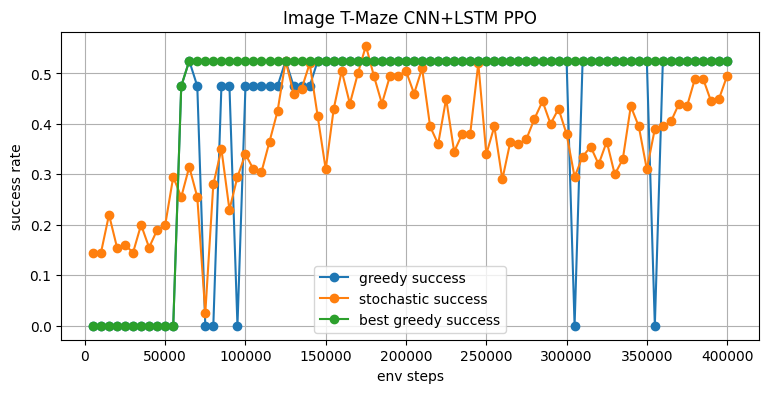

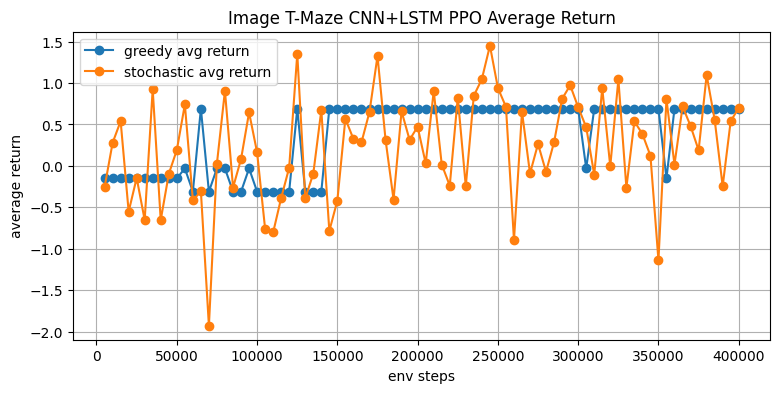

In [32]:
# Colab cell 3: Image T-Maze CNN+LSTM PPO

def train_cnn_lstm_ppo(total_steps=TOTAL_STEPS):
    env = ImageTMaze3ActionEnv(
        corridor_length=CORRIDOR_LEN,
        view_size=LOCAL_VIEW,
        image_size=IMG_SIZE,
        max_steps=MAX_EP_STEPS,
    )
    model = CNNLSTMActorCritic(env.action_space.n, hidden_size=128).to(device)
    opt = optim.Adam(model.parameters(), lr=1e-4)

    rollout_steps = 64
    ppo_epochs = 4
    clip_coef = 0.2
    vf_coef = 0.5
    ent_coef = 1e-3

    global_step = 0
    ep_ret = 0.0
    best_success = -1.0
    episode_returns = deque(maxlen=50)

    obs, _ = env.reset(seed=SEED)
    hidden = model.init_hidden(1)

    metrics = {
        "steps": [],
        "success_greedy": [],
        "success_stochastic": [],
        "avg_return_greedy": [],
        "avg_return_stochastic": [],
        "best_success_greedy": [],
    }

    while global_step < total_steps:
        obs_buf, act_buf, logp_buf, rew_buf, done_buf, val_buf = [], [], [], [], [], []
        hidden0 = (hidden[0].detach().clone(), hidden[1].detach().clone())

        for _ in range(rollout_steps):
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                action, logp, ent, value, hidden = model.step(obs_t, hidden)

            next_obs, reward, term, trunc, info = env.step(action.item())
            done = term or trunc

            obs_buf.append(obs_t.squeeze(0))
            act_buf.append(action.squeeze(0) if action.ndim > 0 else action)
            logp_buf.append(logp.squeeze(0) if logp.ndim > 0 else logp)
            rew_buf.append(torch.tensor(reward, dtype=torch.float32, device=device))
            done_buf.append(torch.tensor(float(done), dtype=torch.float32, device=device))
            val_buf.append(value.squeeze(0) if value.ndim > 0 else value)

            ep_ret += reward
            global_step += 1
            obs = next_obs

            if done:
                episode_returns.append(ep_ret)
                ep_ret = 0.0
                obs, _ = env.reset()
                hidden = model.init_hidden(1)
            else:
                hidden = (hidden[0].detach(), hidden[1].detach())

            if global_step % CHECKPOINT_EVERY == 0:
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(CKPT_DIR, f"image_tmaze_cnn_lstm_ppo_{global_step}.pt"),
                )

            if global_step >= total_steps:
                break

        with torch.no_grad():
            obs_t = to_tensor_obs(obs)
            _, _, _, next_value, _ = model.step(obs_t, hidden)

        rewards = torch.stack(rew_buf)
        dones = torch.stack(done_buf)
        values = torch.stack(val_buf)

        adv, ret = compute_gae(rewards, dones, values, next_value.squeeze(0))
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        obs_seq = torch.stack(obs_buf).unsqueeze(1)   # [T,1,C,H,W]
        act_seq = torch.stack(act_buf).view(-1, 1)
        old_logp = torch.stack(logp_buf).view(-1, 1)
        adv_seq = adv.view(-1, 1)
        ret_seq = ret.view(-1, 1)

        for _ in range(ppo_epochs):
            new_logp, ent, new_values = model.evaluate_seq(obs_seq, act_seq, hidden0)

            ratio = (new_logp - old_logp).exp()
            pg1 = -adv_seq * ratio
            pg2 = -adv_seq * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
            policy_loss = torch.max(pg1, pg2).mean()
            value_loss = 0.5 * (ret_seq - new_values).pow(2).mean()
            ent_loss = ent.mean()
            loss = policy_loss + vf_coef * value_loss - ent_coef * ent_loss

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step()

        if global_step % 5000 < rollout_steps:
            succ_g, avg_ret_g = evaluate_cnn_policy(model, episodes=200, recurrent=True, greedy=True)
            succ_s, avg_ret_s = evaluate_cnn_policy(model, episodes=200, recurrent=True, greedy=False)

            if succ_g > best_success:
                best_success = succ_g
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(CKPT_DIR, "image_tmaze_cnn_lstm_ppo_best.pt"),
                )
                print("⭐ new best CNN+LSTM checkpoint saved")

            metrics["steps"].append(global_step)
            metrics["success_greedy"].append(succ_g)
            metrics["success_stochastic"].append(succ_s)
            metrics["avg_return_greedy"].append(avg_ret_g)
            metrics["avg_return_stochastic"].append(avg_ret_s)
            metrics["best_success_greedy"].append(best_success)

            print(
                f"[Image T-Maze CNN+LSTM PPO] step {global_step:6d} | "
                f"greedy success {succ_g:.3f} | greedy avg_ret {avg_ret_g:.3f} | "
                f"stoch success {succ_s:.3f} | stoch avg_ret {avg_ret_s:.3f} | "
                f"best greedy {best_success:.3f}",
                flush=True,
            )

    env.close()
    return model, metrics


cnn_lstm_model, cnn_lstm_metrics = train_cnn_lstm_ppo(TOTAL_STEPS)

plt.figure(figsize=(9, 4))
plt.plot(cnn_lstm_metrics["steps"], cnn_lstm_metrics["success_greedy"], marker="o", label="greedy success")
plt.plot(cnn_lstm_metrics["steps"], cnn_lstm_metrics["success_stochastic"], marker="o", label="stochastic success")
plt.plot(cnn_lstm_metrics["steps"], cnn_lstm_metrics["best_success_greedy"], marker="o", label="best greedy success")
plt.xlabel("env steps")
plt.ylabel("success rate")
plt.title("Image T-Maze CNN+LSTM PPO")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(cnn_lstm_metrics["steps"], cnn_lstm_metrics["avg_return_greedy"], marker="o", label="greedy avg return")
plt.plot(cnn_lstm_metrics["steps"], cnn_lstm_metrics["avg_return_stochastic"], marker="o", label="stochastic avg return")
plt.xlabel("env steps")
plt.ylabel("average return")
plt.title("Image T-Maze CNN+LSTM PPO Average Return")
plt.legend()
plt.grid(True)
plt.show()

cnn_lstm_video = os.path.join(VID_DIR, "image_tmaze_cnn_lstm_greedy.mp4")
make_video_cnn_policy(cnn_lstm_model, cnn_lstm_video, episodes=3, recurrent=True)
display(Video(cnn_lstm_video, embed=True, width=420))

device: cuda
gpu: Tesla T4
⭐ new best CNN-only checkpoint saved
[Banner T-Maze CNN-only PPO] step   5056 | greedy success 0.000 | greedy avg_ret -0.150 | stoch success 0.120 | stoch avg_ret -0.328 | best greedy 0.000
[Banner T-Maze CNN-only PPO] step  10048 | greedy success 0.000 | greedy avg_ret -0.150 | stoch success 0.170 | stoch avg_ret -0.320 | best greedy 0.000
[Banner T-Maze CNN-only PPO] step  15040 | greedy success 0.000 | greedy avg_ret -0.150 | stoch success 0.170 | stoch avg_ret -0.466 | best greedy 0.000
⭐ new best CNN-only checkpoint saved
[Banner T-Maze CNN-only PPO] step  20000 | greedy success 0.475 | greedy avg_ret 4.762 | stoch success 0.475 | stoch avg_ret 4.714 | best greedy 0.475


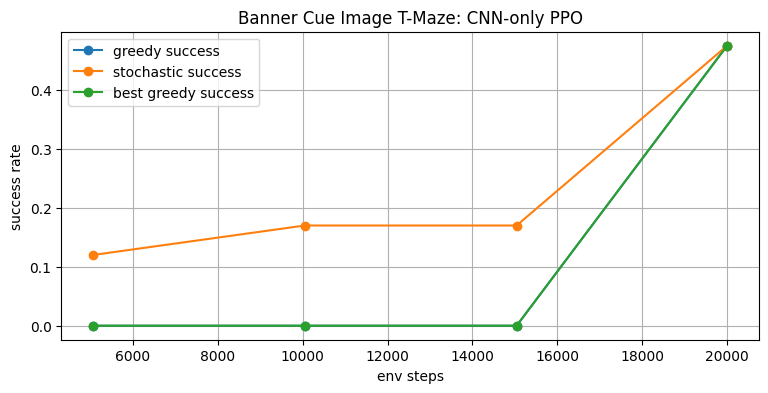

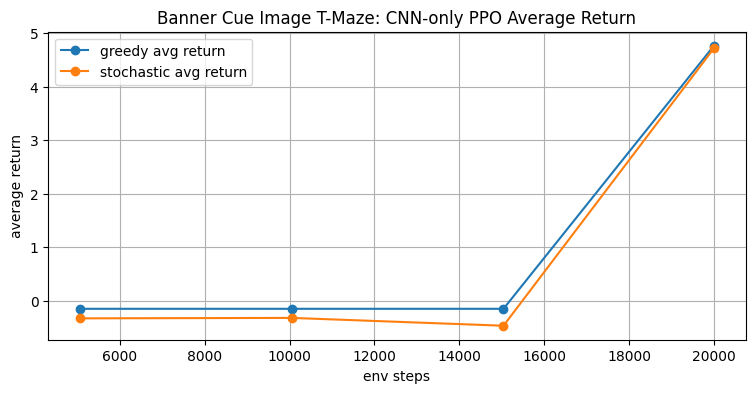

⭐ new best CNN+LSTM checkpoint saved
[Banner T-Maze CNN+LSTM PPO] step   5056 | greedy success 0.000 | greedy avg_ret -0.150 | stoch success 0.110 | stoch avg_ret -0.439 | best greedy 0.000
[Banner T-Maze CNN+LSTM PPO] step  10048 | greedy success 0.000 | greedy avg_ret -0.150 | stoch success 0.150 | stoch avg_ret 0.054 | best greedy 0.000
[Banner T-Maze CNN+LSTM PPO] step  15040 | greedy success 0.000 | greedy avg_ret -0.150 | stoch success 0.140 | stoch avg_ret -0.466 | best greedy 0.000
[Banner T-Maze CNN+LSTM PPO] step  20032 | greedy success 0.000 | greedy avg_ret -0.150 | stoch success 0.060 | stoch avg_ret -0.077 | best greedy 0.000
[Banner T-Maze CNN+LSTM PPO] step  25024 | greedy success 0.000 | greedy avg_ret -0.150 | stoch success 0.100 | stoch avg_ret -0.675 | best greedy 0.000
[Banner T-Maze CNN+LSTM PPO] step  30016 | greedy success 0.000 | greedy avg_ret -0.150 | stoch success 0.150 | stoch avg_ret -0.210 | best greedy 0.000
[Banner T-Maze CNN+LSTM PPO] step  35008 | gre

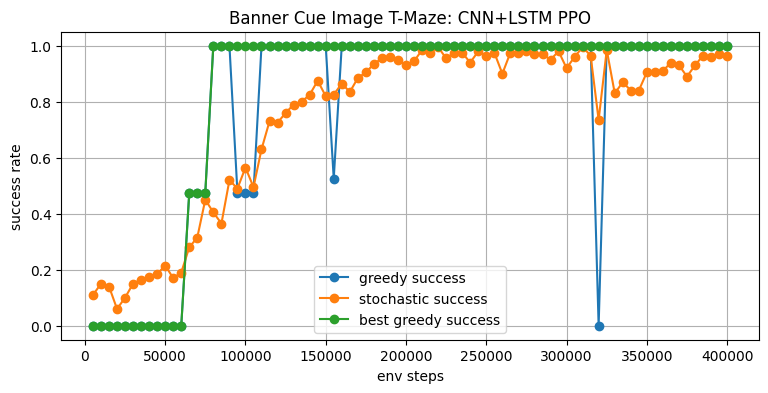

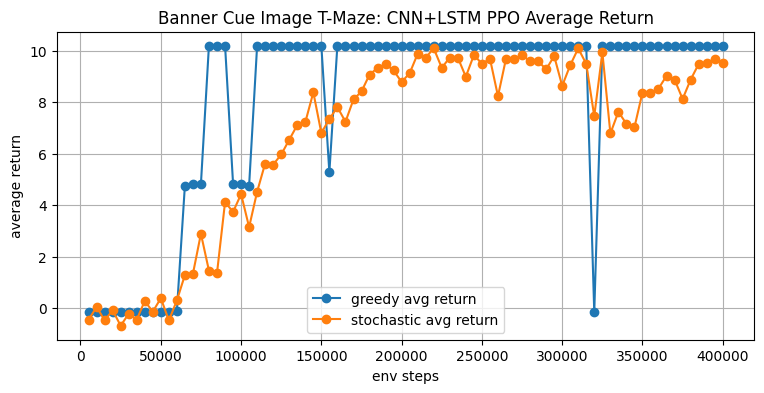

In [33]:
# Colab cell: Image T-Maze with a large colored cue banner at the start
# Cue banner:
#   red banner    => left is correct
#   yellow banner => right is correct
#
# This cell includes:
# - corrected env with banner cue
# - CNN-only PPO
# - CNN+LSTM PPO
# - best checkpoint saving
# - plots
# - videos

!pip -q install gymnasium matplotlib imageio imageio-ffmpeg pillow

import os
import random
import imageio
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from IPython.display import Video, display

# ============================================================
# Config
# ============================================================
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

OUT_DIR = "/content/image_tmaze_banner_compare"
CKPT_DIR = os.path.join(OUT_DIR, "checkpoints")
VID_DIR = os.path.join(OUT_DIR, "videos")
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(VID_DIR, exist_ok=True)

IMG_SIZE = 64
LOCAL_VIEW = 5
CORRIDOR_LEN = 3
MAX_EP_STEPS = CORRIDOR_LEN + 3
TOTAL_STEPS = 200_000
CHECKPOINT_EVERY = 100_000
EVAL_EPISODES = 200

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ============================================================
# Env: Image T-Maze with large colored banner cue
# ============================================================
class ImageTMaze3ActionEnv(gym.Env):
    """
    3-action image T-maze
      0 = forward
      1 = left
      2 = right

    Cue:
      red banner    => left is correct
      yellow banner => right is correct

    The banner is added to the observation at the start state only.
    """
    metadata = {"render_modes": ["rgb_array"]}

    def __init__(
        self,
        corridor_length=3,
        view_size=5,
        image_size=64,
        max_steps=6,
        render_mode="rgb_array",
        banner_fraction=6,   # banner_h = image_size // banner_fraction
    ):
        super().__init__()
        assert view_size % 2 == 1

        self.corridor_length = corridor_length
        self.view_size = view_size
        self.image_size = image_size
        self.max_steps = max_steps
        self.render_mode = render_mode
        self.banner_fraction = banner_fraction

        self.action_space = spaces.Discrete(3)  # 0=forward, 1=left, 2=right
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(3, image_size, image_size), dtype=np.float32
        )

        self.height = corridor_length + 2
        self.width = 3
        self._build_maze()

        self.agent_pos = None
        self.cue = None
        self.steps = 0
        self.done = False

    def _build_maze(self):
        self.maze = np.zeros((self.height, self.width), dtype=np.int32)
        self.maze[1:self.height - 1, 1] = 1
        self.maze[self.height - 2, 0] = 1
        self.maze[self.height - 2, 1] = 1
        self.maze[self.height - 2, 2] = 1

        self.start_pos = (1, 1)
        self.left_goal = (self.height - 2, 0)
        self.right_goal = (self.height - 2, 2)
        self.junction = (self.height - 2, 1)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.agent_pos = self.start_pos
        self.cue = self.np_random.choice([-1, 1])  # -1=left, +1=right
        self.steps = 0
        self.done = False
        return self._get_obs(), self._get_info(success=False)

    def _get_info(self, success=False):
        return {
            "cue": int(self.cue),
            "agent_pos": self.agent_pos,
            "junction": self.agent_pos == self.junction,
            "success": bool(success),
        }

    def step(self, action):
        if self.done:
            raise RuntimeError("Episode done. Call reset().")

        self.steps += 1
        reward = -0.005
        terminated = False
        truncated = False
        success = False

        # before junction: only forward helps
        if self.agent_pos != self.junction:
            if action == 0:
                r, c = self.agent_pos
                nr, nc = r + 1, c
                if self._is_free(nr, nc):
                    self.agent_pos = (nr, nc)
                    reward += 0.1
            else:
                reward -= 0.02

        # at junction: choose left/right; forward = failure
        else:
            if action == 1:
                self.agent_pos = self.left_goal
            elif action == 2:
                self.agent_pos = self.right_goal
            else:
                reward = -1.0
                terminated = True
                self.done = True

        if self.agent_pos == self.left_goal:
            reward = 10.0 if self.cue == -1 else -10.0
            terminated = True
            self.done = True
            success = (self.cue == -1)

        elif self.agent_pos == self.right_goal:
            reward = 10.0 if self.cue == 1 else -10.0
            terminated = True
            self.done = True
            success = (self.cue == 1)

        elif self.steps >= self.max_steps and not terminated:
            truncated = True
            self.done = True

        return self._get_obs(), reward, terminated, truncated, self._get_info(success=success)

    def _inside(self, r, c):
        return 0 <= r < self.height and 0 <= c < self.width

    def _is_free(self, r, c):
        return self._inside(r, c) and self.maze[r, c] == 1

    def _full_rgb_grid(self):
        img = np.zeros((self.height, self.width, 3), dtype=np.float32)
        img[self.maze == 1] = np.array([1.0, 1.0, 1.0], dtype=np.float32)

        lr, lc = self.left_goal
        rr, rc = self.right_goal
        img[lr, lc] = np.array([0.0, 1.0, 0.0], dtype=np.float32)
        img[rr, rc] = np.array([0.0, 1.0, 0.0], dtype=np.float32)

        ar, ac = self.agent_pos
        img[ar, ac] = np.array([0.0, 0.0, 1.0], dtype=np.float32)  # agent = blue
        return img

    def _get_obs(self):
        full = self._full_rgb_grid()

        # local crop around agent
        pad = self.view_size // 2
        padded = np.pad(
            full,
            ((pad, pad), (pad, pad), (0, 0)),
            mode="constant",
            constant_values=0.0,
        )

        ar, ac = self.agent_pos
        ar += pad
        ac += pad
        crop = padded[ar-pad:ar+pad+1, ac-pad:ac+pad+1, :]

        # upsample crop
        scale = self.image_size // self.view_size
        up = np.repeat(np.repeat(crop, scale, axis=0), scale, axis=1)

        if up.shape[0] != self.image_size or up.shape[1] != self.image_size:
            out = np.zeros((self.image_size, self.image_size, 3), dtype=np.float32)
            h = min(self.image_size, up.shape[0])
            w = min(self.image_size, up.shape[1])
            out[:h, :w] = up[:h, :w]
            up = out

        # ------------------------------------------------------
        # BIG CUE BANNER AT START STATE
        # ------------------------------------------------------
        if self.agent_pos == self.start_pos:
            banner_h = self.image_size // self.banner_fraction
            if self.cue == -1:
                # red banner => LEFT
                up[:banner_h, :, :] = np.array([1.0, 0.0, 0.0], dtype=np.float32)
            else:
                # yellow banner => RIGHT
                up[:banner_h, :, :] = np.array([1.0, 1.0, 0.0], dtype=np.float32)

        return np.transpose(up, (2, 0, 1)).astype(np.float32)

    def render(self):
        # render the same observation the agent sees
        obs = self._get_obs()
        return (np.transpose(obs, (1, 2, 0)) * 255).astype(np.uint8)

# ============================================================
# Models
# ============================================================
class CNNEncoder(nn.Module):
    def __init__(self, in_ch=3, img_size=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, 8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1), nn.ReLU(),
            nn.Flatten(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, img_size, img_size)
            self.out_dim = self.net(dummy).shape[-1]

    def forward(self, x):
        return self.net(x)

class CNNActorCritic(nn.Module):
    def __init__(self, num_actions):
        super().__init__()
        self.enc = CNNEncoder(3, IMG_SIZE)
        self.fc = nn.Sequential(nn.Linear(self.enc.out_dim, 256), nn.ReLU())
        self.pi = nn.Linear(256, num_actions)
        self.v = nn.Linear(256, 1)

    def forward(self, x):
        z = self.fc(self.enc(x))
        return self.pi(z), self.v(z).squeeze(-1)

class CNNLSTMActorCritic(nn.Module):
    def __init__(self, num_actions, hidden_size=128):
        super().__init__()
        self.enc = CNNEncoder(3, IMG_SIZE)
        self.fc = nn.Sequential(nn.Linear(self.enc.out_dim, 256), nn.ReLU())
        self.lstm = nn.LSTM(256, hidden_size, num_layers=1)
        self.pi = nn.Linear(hidden_size, num_actions)
        self.v = nn.Linear(hidden_size, 1)
        self.hidden_size = hidden_size

    def init_hidden(self, batch_size=1):
        h = torch.zeros(1, batch_size, self.hidden_size, device=device)
        c = torch.zeros(1, batch_size, self.hidden_size, device=device)
        return (h, c)

    def step(self, x, hidden):
        z = self.fc(self.enc(x)).unsqueeze(0)
        out, hidden = self.lstm(z, hidden)
        out = out.squeeze(0)
        logits = self.pi(out)
        value = self.v(out).squeeze(-1)
        dist = Categorical(logits=logits)
        action = dist.sample()
        logp = dist.log_prob(action)
        ent = dist.entropy()
        return action, logp, ent, value, hidden

    def greedy_step(self, x, hidden):
        z = self.fc(self.enc(x)).unsqueeze(0)
        out, hidden = self.lstm(z, hidden)
        out = out.squeeze(0)
        logits = self.pi(out)
        value = self.v(out).squeeze(-1)
        action = torch.argmax(logits, dim=-1)
        return action, value, hidden

    def evaluate_seq(self, obs_seq, act_seq, hidden0):
        T, B = act_seq.shape
        x = obs_seq.reshape(T * B, *obs_seq.shape[2:])
        z = self.fc(self.enc(x)).view(T, B, -1)
        out, _ = self.lstm(z, hidden0)
        logits = self.pi(out)
        values = self.v(out).squeeze(-1)
        dist = Categorical(logits=logits)
        logp = dist.log_prob(act_seq)
        ent = dist.entropy()
        return logp, ent, values

# ============================================================
# Helpers
# ============================================================
def to_tensor_obs(obs):
    return torch.from_numpy(np.asarray(obs, dtype=np.float32)).unsqueeze(0).to(device)

def compute_gae(rewards, dones, values, next_value, gamma=0.99, lam=0.95):
    T = len(rewards)
    adv = torch.zeros(T, device=device)
    last = 0.0
    for t in reversed(range(T)):
        if t == T - 1:
            next_nonterminal = 1.0 - dones[t]
            next_values = next_value
        else:
            next_nonterminal = 1.0 - dones[t]
            next_values = values[t + 1]
        delta = rewards[t] + gamma * next_values * next_nonterminal - values[t]
        last = delta + gamma * lam * next_nonterminal * last
        adv[t] = last
    ret = adv + values
    return adv, ret

def evaluate_policy(model, recurrent=False, greedy=True, episodes=EVAL_EPISODES):
    env = ImageTMaze3ActionEnv(
        corridor_length=CORRIDOR_LEN,
        view_size=LOCAL_VIEW,
        image_size=IMG_SIZE,
        max_steps=MAX_EP_STEPS,
    )
    success = 0
    ret_sum = 0.0

    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + 10000 + ep)
        done = False
        ep_ret = 0.0
        final_success = False
        hidden = model.init_hidden(1) if recurrent else None

        while not done:
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                if recurrent:
                    if greedy:
                        action, _, hidden = model.greedy_step(obs_t, hidden)
                        action = action.item()
                    else:
                        action, _, _, _, hidden = model.step(obs_t, hidden)
                        action = action.item()
                else:
                    logits, _ = model(obs_t)
                    if greedy:
                        action = torch.argmax(logits, dim=-1).item()
                    else:
                        dist = Categorical(logits=logits)
                        action = dist.sample().item()

            obs, reward, term, trunc, info = env.step(action)
            ep_ret += reward
            final_success = info["success"]
            done = term or trunc

        ret_sum += ep_ret
        if final_success:
            success += 1

    env.close()
    return success / episodes, ret_sum / episodes

def make_video(model, path, recurrent=False, episodes=3):
    env = ImageTMaze3ActionEnv(
        corridor_length=CORRIDOR_LEN,
        view_size=LOCAL_VIEW,
        image_size=IMG_SIZE,
        max_steps=MAX_EP_STEPS,
        render_mode="rgb_array",
    )
    frames = []

    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + 3000 + ep)
        done = False
        hidden = model.init_hidden(1) if recurrent else None

        while not done:
            frames.append(env.render())
            obs_t = to_tensor_obs(obs)

            with torch.no_grad():
                if recurrent:
                    action, _, hidden = model.greedy_step(obs_t, hidden)
                    action = action.item()
                else:
                    logits, _ = model(obs_t)
                    action = torch.argmax(logits, dim=-1).item()

            obs, reward, term, trunc, info = env.step(action)
            done = term or trunc

        for _ in range(8):
            frames.append(env.render())

    with imageio.get_writer(path, fps=4) as writer:
        for f in frames:
            writer.append_data(f)

    env.close()

# ============================================================
# Training: CNN-only PPO
# ============================================================
def train_cnn_ppo(total_steps=TOTAL_STEPS):
    env = ImageTMaze3ActionEnv(
        corridor_length=CORRIDOR_LEN,
        view_size=LOCAL_VIEW,
        image_size=IMG_SIZE,
        max_steps=MAX_EP_STEPS,
    )
    model = CNNActorCritic(env.action_space.n).to(device)
    opt = optim.Adam(model.parameters(), lr=2.5e-4)

    rollout_steps = 64
    ppo_epochs = 4
    clip_coef = 0.2
    vf_coef = 0.5
    ent_coef = 1e-3

    global_step = 0
    ep_ret = 0.0
    best_success = -1.0
    obs, _ = env.reset(seed=SEED)

    metrics = {
        "steps": [],
        "success_greedy": [],
        "success_stochastic": [],
        "avg_return_greedy": [],
        "avg_return_stochastic": [],
        "best_success_greedy": [],
    }

    while global_step < total_steps:
        obs_buf, act_buf, logp_buf, rew_buf, done_buf, val_buf = [], [], [], [], [], []

        for _ in range(rollout_steps):
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                logits, value = model(obs_t)
                dist = Categorical(logits=logits)
                action = dist.sample()
                logp = dist.log_prob(action)

            next_obs, reward, term, trunc, info = env.step(action.item())
            done = term or trunc

            obs_buf.append(obs_t.squeeze(0))
            act_buf.append(action.squeeze(0) if action.ndim > 0 else action)
            logp_buf.append(logp.squeeze(0) if logp.ndim > 0 else logp)
            rew_buf.append(torch.tensor(reward, dtype=torch.float32, device=device))
            done_buf.append(torch.tensor(float(done), dtype=torch.float32, device=device))
            val_buf.append(value.squeeze(0) if value.ndim > 0 else value)

            ep_ret += reward
            global_step += 1
            obs = next_obs

            if done:
                ep_ret = 0.0
                obs, _ = env.reset()

            if global_step % CHECKPOINT_EVERY == 0:
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(CKPT_DIR, f"banner_tmaze_cnn_ppo_{global_step}.pt"),
                )

            if global_step >= total_steps:
                break

        with torch.no_grad():
            obs_t = to_tensor_obs(obs)
            _, next_value = model(obs_t)

        rewards = torch.stack(rew_buf)
        dones = torch.stack(done_buf)
        values = torch.stack(val_buf)
        adv, ret = compute_gae(rewards, dones, values, next_value.squeeze(0))
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        obs_batch = torch.stack(obs_buf)
        act_batch = torch.stack(act_buf)
        old_logp = torch.stack(logp_buf)

        for _ in range(ppo_epochs):
            logits, new_values = model(obs_batch)
            dist = Categorical(logits=logits)
            new_logp = dist.log_prob(act_batch)
            ent = dist.entropy().mean()

            ratio = (new_logp - old_logp).exp()
            pg1 = -adv * ratio
            pg2 = -adv * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
            policy_loss = torch.max(pg1, pg2).mean()
            value_loss = 0.5 * (ret - new_values).pow(2).mean()
            loss = policy_loss + vf_coef * value_loss - ent_coef * ent

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step()

        if global_step % 5000 < rollout_steps:
            succ_g, avg_ret_g = evaluate_policy(model, recurrent=False, greedy=True)
            succ_s, avg_ret_s = evaluate_policy(model, recurrent=False, greedy=False)

            if succ_g > best_success:
                best_success = succ_g
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(CKPT_DIR, "banner_tmaze_cnn_ppo_best.pt"),
                )
                print("⭐ new best CNN-only checkpoint saved")

            metrics["steps"].append(global_step)
            metrics["success_greedy"].append(succ_g)
            metrics["success_stochastic"].append(succ_s)
            metrics["avg_return_greedy"].append(avg_ret_g)
            metrics["avg_return_stochastic"].append(avg_ret_s)
            metrics["best_success_greedy"].append(best_success)

            print(
                f"[Banner T-Maze CNN-only PPO] step {global_step:6d} | "
                f"greedy success {succ_g:.3f} | greedy avg_ret {avg_ret_g:.3f} | "
                f"stoch success {succ_s:.3f} | stoch avg_ret {avg_ret_s:.3f} | "
                f"best greedy {best_success:.3f}",
                flush=True,
            )

    env.close()
    return model, metrics

# ============================================================
# Training: CNN+LSTM PPO
# ============================================================
def train_cnn_lstm_ppo(total_steps=TOTAL_STEPS):
    env = ImageTMaze3ActionEnv(
        corridor_length=CORRIDOR_LEN,
        view_size=LOCAL_VIEW,
        image_size=IMG_SIZE,
        max_steps=MAX_EP_STEPS,
    )
    model = CNNLSTMActorCritic(env.action_space.n, hidden_size=128).to(device)
    opt = optim.Adam(model.parameters(), lr=1e-4)

    rollout_steps = 64
    ppo_epochs = 4
    clip_coef = 0.2
    vf_coef = 0.5
    ent_coef = 1e-3

    global_step = 0
    ep_ret = 0.0
    best_success = -1.0
    obs, _ = env.reset(seed=SEED)
    hidden = model.init_hidden(1)

    metrics = {
        "steps": [],
        "success_greedy": [],
        "success_stochastic": [],
        "avg_return_greedy": [],
        "avg_return_stochastic": [],
        "best_success_greedy": [],
    }

    while global_step < total_steps:
        obs_buf, act_buf, logp_buf, rew_buf, done_buf, val_buf = [], [], [], [], [], []
        hidden0 = (hidden[0].detach().clone(), hidden[1].detach().clone())

        for _ in range(rollout_steps):
            obs_t = to_tensor_obs(obs)
            with torch.no_grad():
                action, logp, ent, value, hidden = model.step(obs_t, hidden)

            next_obs, reward, term, trunc, info = env.step(action.item())
            done = term or trunc

            obs_buf.append(obs_t.squeeze(0))
            act_buf.append(action.squeeze(0) if action.ndim > 0 else action)
            logp_buf.append(logp.squeeze(0) if logp.ndim > 0 else logp)
            rew_buf.append(torch.tensor(reward, dtype=torch.float32, device=device))
            done_buf.append(torch.tensor(float(done), dtype=torch.float32, device=device))
            val_buf.append(value.squeeze(0) if value.ndim > 0 else value)

            ep_ret += reward
            global_step += 1
            obs = next_obs

            if done:
                ep_ret = 0.0
                obs, _ = env.reset()
                hidden = model.init_hidden(1)
            else:
                hidden = (hidden[0].detach(), hidden[1].detach())

            if global_step % CHECKPOINT_EVERY == 0:
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(CKPT_DIR, f"banner_tmaze_cnn_lstm_ppo_{global_step}.pt"),
                )

            if global_step >= total_steps:
                break

        with torch.no_grad():
            obs_t = to_tensor_obs(obs)
            _, _, _, next_value, _ = model.step(obs_t, hidden)

        rewards = torch.stack(rew_buf)
        dones = torch.stack(done_buf)
        values = torch.stack(val_buf)
        adv, ret = compute_gae(rewards, dones, values, next_value.squeeze(0))
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        obs_seq = torch.stack(obs_buf).unsqueeze(1)   # [T,1,C,H,W]
        act_seq = torch.stack(act_buf).view(-1, 1)
        old_logp = torch.stack(logp_buf).view(-1, 1)
        adv_seq = adv.view(-1, 1)
        ret_seq = ret.view(-1, 1)

        for _ in range(ppo_epochs):
            new_logp, ent, new_values = model.evaluate_seq(obs_seq, act_seq, hidden0)

            ratio = (new_logp - old_logp).exp()
            pg1 = -adv_seq * ratio
            pg2 = -adv_seq * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
            policy_loss = torch.max(pg1, pg2).mean()
            value_loss = 0.5 * (ret_seq - new_values).pow(2).mean()
            ent_loss = ent.mean()
            loss = policy_loss + vf_coef * value_loss - ent_coef * ent_loss

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step()

        if global_step % 5000 < rollout_steps:
            succ_g, avg_ret_g = evaluate_policy(model, recurrent=True, greedy=True)
            succ_s, avg_ret_s = evaluate_policy(model, recurrent=True, greedy=False)

            if succ_g > best_success:
                best_success = succ_g
                torch.save(
                    {
                        "step": global_step,
                        "model_state": model.state_dict(),
                        "opt_state": opt.state_dict(),
                        "best_success_greedy": best_success,
                    },
                    os.path.join(CKPT_DIR, "banner_tmaze_cnn_lstm_ppo_best.pt"),
                )
                print("⭐ new best CNN+LSTM checkpoint saved")

            metrics["steps"].append(global_step)
            metrics["success_greedy"].append(succ_g)
            metrics["success_stochastic"].append(succ_s)
            metrics["avg_return_greedy"].append(avg_ret_g)
            metrics["avg_return_stochastic"].append(avg_ret_s)
            metrics["best_success_greedy"].append(best_success)

            print(
                f"[Banner T-Maze CNN+LSTM PPO] step {global_step:6d} | "
                f"greedy success {succ_g:.3f} | greedy avg_ret {avg_ret_g:.3f} | "
                f"stoch success {succ_s:.3f} | stoch avg_ret {avg_ret_s:.3f} | "
                f"best greedy {best_success:.3f}",
                flush=True,
            )

    env.close()
    return model, metrics

# ============================================================
# Run CNN-only PPO
# ============================================================
cnn_only_model, cnn_only_metrics = train_cnn_ppo(20000)

plt.figure(figsize=(9, 4))
plt.plot(cnn_only_metrics["steps"], cnn_only_metrics["success_greedy"], marker="o", label="greedy success")
plt.plot(cnn_only_metrics["steps"], cnn_only_metrics["success_stochastic"], marker="o", label="stochastic success")
plt.plot(cnn_only_metrics["steps"], cnn_only_metrics["best_success_greedy"], marker="o", label="best greedy success")
plt.xlabel("env steps")
plt.ylabel("success rate")
plt.title("Banner Cue Image T-Maze: CNN-only PPO")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(cnn_only_metrics["steps"], cnn_only_metrics["avg_return_greedy"], marker="o", label="greedy avg return")
plt.plot(cnn_only_metrics["steps"], cnn_only_metrics["avg_return_stochastic"], marker="o", label="stochastic avg return")
plt.xlabel("env steps")
plt.ylabel("average return")
plt.title("Banner Cue Image T-Maze: CNN-only PPO Average Return")
plt.legend()
plt.grid(True)
plt.show()

cnn_only_video = os.path.join(VID_DIR, "banner_tmaze_cnn_only_greedy.mp4")
make_video(cnn_only_model, cnn_only_video, recurrent=False, episodes=3)
display(Video(cnn_only_video, embed=True, width=420))

# ============================================================
# Run CNN+LSTM PPO
# ============================================================
cnn_lstm_model, cnn_lstm_metrics = train_cnn_lstm_ppo(400_000)

plt.figure(figsize=(9, 4))
plt.plot(cnn_lstm_metrics["steps"], cnn_lstm_metrics["success_greedy"], marker="o", label="greedy success")
plt.plot(cnn_lstm_metrics["steps"], cnn_lstm_metrics["success_stochastic"], marker="o", label="stochastic success")
plt.plot(cnn_lstm_metrics["steps"], cnn_lstm_metrics["best_success_greedy"], marker="o", label="best greedy success")
plt.xlabel("env steps")
plt.ylabel("success rate")
plt.title("Banner Cue Image T-Maze: CNN+LSTM PPO")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(cnn_lstm_metrics["steps"], cnn_lstm_metrics["avg_return_greedy"], marker="o", label="greedy avg return")
plt.plot(cnn_lstm_metrics["steps"], cnn_lstm_metrics["avg_return_stochastic"], marker="o", label="stochastic avg return")
plt.xlabel("env steps")
plt.ylabel("average return")
plt.title("Banner Cue Image T-Maze: CNN+LSTM PPO Average Return")
plt.legend()
plt.grid(True)
plt.show()

cnn_lstm_video = os.path.join(VID_DIR, "banner_tmaze_cnn_lstm_greedy.mp4")
make_video(cnn_lstm_model, cnn_lstm_video, recurrent=True, episodes=3)
display(Video(cnn_lstm_video, embed=True, width=420))

In [ ]:
# how small can we make the yellow banner for policy to become unstable

There is no single exact size from theory alone, because the instability threshold depends on:

* your image size (64x64)
* banner brightness / contrast
* whether red and yellow are equally easy to detect
* optimizer seed
* CNN architecture
* reward shaping
* corridor length

But from your logs, you are in a regime where the banner cue is now strong enough for stable learning, so the practical way to find the instability boundary is to shrink it systematically.

Good way to test it

Right now you use:

banner_h = self.image_size // 6


* 64 // 6 = 10 pixels tall

That is fairly large.

A good ablation ladder is:

* 64 // 6 = 10 px
* 64 // 8 = 8 px
* 64 // 10 = 6 px
* 64 // 12 = 5 px
* 64 // 16 = 4 px
* 64 // 21 = 3 px
* 64 // 32 = 2 px

My guess for the instability zone

Given your earlier failures with tiny/local cue encoding and success with the big banner, I would expect:

* 8–10 px: probably still stable
* 5–6 px: likely borderline
* 3–4 px: likely unstable or highly seed-sensitive
* 2 px: probably too weak for reliable learning

So the likely transition is somewhere around:

4 to 6 pixels tall

Best experiment

Instead of asking “what is the smallest possible,” define:

* stable = reaches greedy success >= 0.95 in at least 2/3 seeds by 150k steps
* unstable = sometimes solves, sometimes gets stuck near 0.5
* too small = usually never solves

Then run:

* banner height = 10, 8, 6, 5, 4, 3

with 3 seeds each.

That is related to “minimum button size,” but not identical.
Why it is relevant

A browser agent also has to detect and use small visual targets, like:

* buttons
* banners
* icons
* form fields
* labels

So if your agent fails once the cue shrinks below a certain size, that tells you something about:

* visual resolution needs
* encoder limits
* salience thresholds
* memory reliability after perception

Why it is not the same as real browser button size

A real button depends on more than pixel height:

* text inside the button
* contrast
* shape and border
* surrounding clutter
* DOM structure
* whether the model can use accessibility text or HTML
* whether the action space is coordinate-based or DOM-based

So your banner-size ablation is closer to:

minimum recognizable cue size in a simplified visual RL setting

not:

universal minimum browser button size for all agents

What it can still tell you

It can give you useful engineering insight like:

* if cues smaller than 4 px become unstable, then your visual encoder is operating near its limit
* if 8 px is robust but 4 px is not, then small UI elements may need enlargement, zoom, cropping, or auxiliary signals
* if performance depends strongly on cue size, the agent may need better perception rather than better memory

Better interpretation

I would phrase it like this:

This ablation estimates the minimum visual cue size needed for the agent to reliably perceive and use information.

That is a valuable result for UI agents, because buttons are just one kind of visual cue.

If you really care about browser buttons

A closer experiment would be:

* render actual button-like rectangles
* vary width, height, font size, and contrast
* maybe include distractor buttons
* ask the agent to click the correct one

That would be a much better “minimum recognizable button size” study.

Short answer

Yes, it is important, because it can estimate the minimum visual salience your agent needs to recognize and use a cue. But it is only an indirect proxy for real browser button recognition, not a universal minimum button-size rule.


Should use heatmap to see if cue is detected correctly or not. Yes use the checkpoints under 'Colab Notebooks'/...checked... we can comapare vs another checkpoint which we have to make which is 1.0.

In [ ]:
# Colab cell: Grad-CAM + LSTM hidden-state heat map for CNN+LSTM Image T-Maze
#
# Assumes you already trained a model with the CNNLSTMActorCritic class and
# ImageTMaze3ActionEnv from earlier cells.
#
# This cell:
# 1. wraps the model so we can capture last-conv activations
# 2. runs one episode with greedy policy
# 3. computes Grad-CAM on selected timesteps
# 4. plots LSTM hidden-state heatmap over time
# 5. overlays Grad-CAM on the input frame
#
# If your trained model variable has a different name, change MODEL below.

!pip -q install matplotlib pillow

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# ------------------------------------------------------------------
# Pick your trained model here
# ------------------------------------------------------------------
# Example:
# MODEL = cnn_lstm_model
MODEL = cnn_lstm_model

MODEL.eval()


# ------------------------------------------------------------------
# Utilities
# ------------------------------------------------------------------
def tensor_obs(obs):
    return torch.from_numpy(np.asarray(obs, dtype=np.float32)).unsqueeze(0).to(device)

def chw_to_hwc(img_chw):
    return np.transpose(img_chw, (1, 2, 0))

def normalize_map(x):
    x = x - x.min()
    denom = x.max() - x.min()
    if denom < 1e-8:
        return np.zeros_like(x)
    return x / denom

def overlay_heatmap_on_image(img_hwc, heatmap, alpha=0.45):
    """
    img_hwc: float image in [0,1], shape [H,W,3]
    heatmap: float map in [H,W], normalized to [0,1]
    """
    cmap = plt.get_cmap("jet")
    heat_rgb = cmap(heatmap)[..., :3]
    out = (1 - alpha) * img_hwc + alpha * heat_rgb
    return np.clip(out, 0.0, 1.0)


# ------------------------------------------------------------------
# Grad-CAM wrapper for the CNN encoder
# ------------------------------------------------------------------
class CNNLSTMGradCAMWrapper(torch.nn.Module):
    def __init__(self, actor_critic):
        super().__init__()
        self.model = actor_critic
        self.activations = None
        self.gradients = None

        # We want the last conv feature map before flatten.
        # Earlier code used:
        # Conv2d, ReLU, Conv2d, ReLU, Conv2d, ReLU, Flatten
        # So index 4 is the last Conv2d.
        target_layer = self.model.enc.net[4]

        def forward_hook(module, inputs, output):
            self.activations = output

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        self._fh = target_layer.register_forward_hook(forward_hook)
        self._bh = target_layer.register_full_backward_hook(backward_hook)

    def remove_hooks(self):
        self._fh.remove()
        self._bh.remove()

    def forward_with_hidden(self, obs_t, hidden):
        """
        Forward pass that also preserves the hidden transition exactly like greedy_step.
        Returns logits, value, next_hidden.
        """
        z = self.model.fc(self.model.enc(obs_t)).unsqueeze(0)
        out, next_hidden = self.model.lstm(z, hidden)
        out = out.squeeze(0)
        logits = self.model.pi(out)
        value = self.model.v(out).squeeze(-1)
        return logits, value, next_hidden

    def gradcam_for_action(self, obs_t, hidden, action_idx=None):
        """
        Compute Grad-CAM for one observation and one recurrent hidden state.
        action_idx:
          None => use greedy action
          int  => use provided action index
        Returns:
          cam [H,W], logits [A], value scalar, chosen action int, next_hidden
        """
        self.model.zero_grad(set_to_none=True)
        self.activations = None
        self.gradients = None

        logits, value, next_hidden = self.forward_with_hidden(obs_t, hidden)

        if action_idx is None:
            action_idx = int(torch.argmax(logits, dim=-1).item())

        score = logits[0, action_idx]
        score.backward(retain_graph=True)

        # activations/grads shape: [B,C,H,W]
        acts = self.activations.detach()[0]
        grads = self.gradients.detach()[0]

        # Grad-CAM weights: global-average-pool gradients over spatial dims
        weights = grads.mean(dim=(1, 2), keepdim=True)   # [C,1,1]
        cam = (weights * acts).sum(dim=0)                # [H,W]
        cam = F.relu(cam)

        cam = cam.cpu().numpy()
        cam = normalize_map(cam)

        # upscale to input resolution
        H_in, W_in = obs_t.shape[-2:]
        cam_up = torch.from_numpy(cam).unsqueeze(0).unsqueeze(0).float()
        cam_up = F.interpolate(cam_up, size=(H_in, W_in), mode="bilinear", align_corners=False)
        cam_up = cam_up.squeeze().cpu().numpy()
        cam_up = normalize_map(cam_up)

        return cam_up, logits.detach().cpu().numpy()[0], float(value.item()), action_idx, next_hidden


wrapper = CNNLSTMGradCAMWrapper(MODEL)


# ------------------------------------------------------------------
# Run one greedy episode and collect hidden states / frames
# ------------------------------------------------------------------
def rollout_episode_with_hidden(model, seed=123):
    env = ImageTMaze3ActionEnv(
        corridor_length=CORRIDOR_LEN,
        view_size=LOCAL_VIEW,
        image_size=IMG_SIZE,
        max_steps=MAX_EP_STEPS,
        render_mode="rgb_array",
    )

    obs, info = env.reset(seed=seed)
    hidden = model.init_hidden(1)

    records = []
    done = False
    t = 0

    while not done:
        obs_t = tensor_obs(obs)
        with torch.no_grad():
            action, _, hidden_next = model.greedy_step(obs_t, hidden)

            # Also record logits/value from the same hidden state
            z = model.fc(model.enc(obs_t)).unsqueeze(0)
            out, _ = model.lstm(z, hidden)
            out = out.squeeze(0)
            logits = model.pi(out)
            value = model.v(out).squeeze(-1)

        records.append({
            "t": t,
            "obs": obs.copy(),
            "frame": env.render().copy(),
            "hidden_h": hidden[0].detach().cpu().numpy()[0, 0].copy(),
            "hidden_c": hidden[1].detach().cpu().numpy()[0, 0].copy(),
            "logits": logits.detach().cpu().numpy()[0].copy(),
            "value": float(value.item()),
            "action": int(action.item()),
            "agent_pos": info.get("agent_pos"),
            "cue": info.get("cue"),
            "junction": info.get("junction"),
        })

        obs, reward, term, trunc, info = env.step(int(action.item()))
        hidden = (hidden_next[0].detach(), hidden_next[1].detach())
        done = term or trunc
        t += 1

    env.close()
    return records


records = rollout_episode_with_hidden(MODEL, seed=SEED + 77)

print("Episode length:", len(records))
print("Cue:", records[0]["cue"])
for r in records:
    print(
        f"t={r['t']} action={r['action']} "
        f"logits={np.round(r['logits'], 3)} "
        f"value={r['value']:.3f} "
        f"pos={r['agent_pos']} junction={r['junction']}"
    )


# ------------------------------------------------------------------
# Hidden-state heat maps
# ------------------------------------------------------------------
def plot_hidden_state_heatmaps(records):
    H = np.stack([r["hidden_h"] for r in records], axis=0)  # [T, hidden]
    C = np.stack([r["hidden_c"] for r in records], axis=0)  # [T, hidden]

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

    im0 = axes[0].imshow(H.T, aspect="auto", interpolation="nearest")
    axes[0].set_title("LSTM hidden state h over time")
    axes[0].set_xlabel("time step")
    axes[0].set_ylabel("hidden unit")
    for t, r in enumerate(records):
        if r["junction"]:
            axes[0].axvline(t, color="white", linestyle="--", linewidth=1)

    im1 = axes[1].imshow(C.T, aspect="auto", interpolation="nearest")
    axes[1].set_title("LSTM cell state c over time")
    axes[1].set_xlabel("time step")
    axes[1].set_ylabel("cell unit")
    for t, r in enumerate(records):
        if r["junction"]:
            axes[1].axvline(t, color="white", linestyle="--", linewidth=1)

    plt.colorbar(im0, ax=axes[0], fraction=0.02, pad=0.02)
    plt.colorbar(im1, ax=axes[1], fraction=0.02, pad=0.02)
    plt.show()


plot_hidden_state_heatmaps(records)


# ------------------------------------------------------------------
# Pick interesting timesteps for Grad-CAM
# Usually:
# - t=0 : cue visible
# - middle corridor
# - junction step
# ------------------------------------------------------------------
def choose_key_timesteps(records):
    key = []
    if len(records) > 0:
        key.append(0)

    if len(records) > 2:
        key.append(len(records) // 2)

    junction_ts = [r["t"] for r in records if r["junction"]]
    if len(junction_ts) > 0:
        key.append(junction_ts[0])

    # unique and sorted
    key = sorted(set(key))
    return key


key_ts = choose_key_timesteps(records)
print("Selected timesteps for Grad-CAM:", key_ts)


# ------------------------------------------------------------------
# Recreate hidden states at selected timesteps and compute Grad-CAM
# ------------------------------------------------------------------
def get_hidden_before_t(model, records, t_target):
    """
    Replays from start until just before t_target action.
    Returns hidden state corresponding to records[t_target].
    """
    env = ImageTMaze3ActionEnv(
        corridor_length=CORRIDOR_LEN,
        view_size=LOCAL_VIEW,
        image_size=IMG_SIZE,
        max_steps=MAX_EP_STEPS,
        render_mode="rgb_array",
    )
    obs, _ = env.reset(seed=SEED + 77)
    hidden = model.init_hidden(1)

    for t in range(t_target):
        obs_t = tensor_obs(obs)
        with torch.no_grad():
            action, _, hidden_next = model.greedy_step(obs_t, hidden)
        obs, reward, term, trunc, info = env.step(int(action.item()))
        hidden = (hidden_next[0].detach(), hidden_next[1].detach())

    env.close()
    return hidden


def plot_gradcam_panels(wrapper, model, records, timesteps):
    n = len(timesteps)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n), constrained_layout=True)
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, t in enumerate(timesteps):
        rec = records[t]
        obs = rec["obs"]
        obs_t = tensor_obs(obs)
        hidden = get_hidden_before_t(model, records, t)

        cam, logits, value, action_idx, _ = wrapper.gradcam_for_action(obs_t, hidden, action_idx=None)

        img_hwc = chw_to_hwc(obs)
        overlay = overlay_heatmap_on_image(img_hwc, cam, alpha=0.45)

        # raw obs
        axes[row, 0].imshow(img_hwc)
        axes[row, 0].set_title(
            f"Obs t={t}\ncue={rec['cue']} pos={rec['agent_pos']} junction={rec['junction']}"
        )
        axes[row, 0].axis("off")

        # heatmap only
        axes[row, 1].imshow(cam, cmap="jet")
        axes[row, 1].set_title(
            f"Grad-CAM t={t}\naction={action_idx} logits={np.round(logits,2)} value={value:.2f}"
        )
        axes[row, 1].axis("off")

        # overlay
        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title("Overlay")
        axes[row, 2].axis("off")

    plt.show()


plot_gradcam_panels(wrapper, MODEL, records, key_ts)


# ------------------------------------------------------------------
# Optional: compare cue A vs cue B episodes
# Finds one left-cue and one right-cue episode and plots first frame CAM
# ------------------------------------------------------------------
def rollout_until_cue(model, seed):
    recs = rollout_episode_with_hidden(model, seed=seed)
    return recs

def compare_two_cues(wrapper, model, seed_left=1001, seed_right=1002, max_tries=100):
    left_recs = None
    right_recs = None

    s = seed_left
    for _ in range(max_tries):
        recs = rollout_episode_with_hidden(model, seed=s)
        cue = recs[0]["cue"]
        if cue == -1:
            left_recs = recs
            break
        s += 1

    s = seed_right
    for _ in range(max_tries):
        recs = rollout_episode_with_hidden(model, seed=s)
        cue = recs[0]["cue"]
        if cue == 1:
            right_recs = recs
            break
        s += 1

    if left_recs is None or right_recs is None:
        print("Could not find both cue types.")
        return

    fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)

    for row, recs in enumerate([left_recs, right_recs]):
        obs = recs[0]["obs"]
        obs_t = tensor_obs(obs)
        hidden = MODEL.init_hidden(1)
        cam, logits, value, action_idx, _ = wrapper.gradcam_for_action(obs_t, hidden, action_idx=None)

        img_hwc = chw_to_hwc(obs)
        overlay = overlay_heatmap_on_image(img_hwc, cam, alpha=0.45)

        label = "LEFT cue" if recs[0]["cue"] == -1 else "RIGHT cue"

        axes[row, 0].imshow(img_hwc)
        axes[row, 0].set_title(f"{label}: raw obs")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(cam, cmap="jet")
        axes[row, 1].set_title(f"{label}: Grad-CAM")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title(f"{label}: overlay")
        axes[row, 2].axis("off")

    plt.show()


compare_two_cues(wrapper, MODEL)


# ------------------------------------------------------------------
# Optional: plot action logits over time
# ------------------------------------------------------------------
def plot_logits_over_time(records):
    logits = np.stack([r["logits"] for r in records], axis=0)  # [T, A]
    plt.figure(figsize=(10, 4))
    for a in range(logits.shape[1]):
        plt.plot(logits[:, a], marker="o", label=f"action {a}")
    for t, r in enumerate(records):
        if r["junction"]:
            plt.axvline(t, color="black", linestyle="--", linewidth=1)
    plt.xlabel("time step")
    plt.ylabel("logit")
    plt.title("Policy logits over time")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_logits_over_time(records)


# ------------------------------------------------------------------
# Cleanup note
# ------------------------------------------------------------------
# When done:
# wrapper.remove_hooks()